In [12]:
from core import AnalysisConfig, Reference, ObsType
from utils import Analyzer, ResultsManager
from utils.workdirectory import WorkDirectory
from utils.plot_config import PlotLimits, CMSPlotStyle
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import numpy as np

PROJECTDIR = Path('/eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_New/')

In [3]:
%config InlineBackend.figure_format = 'retina'

In [4]:
def boxplot_UL_by_type_stats(df: pd.DataFrame, outfile, plot_style=None, show_shadows=False, box_width=0.5):
    """
    Create a CMS-style boxplot showing UL values by observation type with statistics table below
    
    Parameters:
    - df: DataFrame with data
    - outfile: Output filename for the plot
    - plot_style: CMSPlotStyle object (optional, uses default if not provided)
    - show_shadows: Whether to show box shadows (default False)
    - box_width: Width of the boxes (default 0.5)
    """
    # Use default style if none provided
    if plot_style is None:
        plot_style = CMSPlotStyle()
    
    # Create figure with two subplots - main plot and stats table below
    figsize = plot_style.figsize
    fig = plt.figure(figsize=figsize)
    
    # Main boxplot (top, larger) and stats table (bottom, smaller)
    gs = fig.add_gridspec(6, 1, hspace=0.0, height_ratios=[2, 2, 2, 2, 0.15, 2])
    ax_main = fig.add_subplot(gs[0:4, 0])
    ax_stats = fig.add_subplot(gs[5, 0])
    
    # Apply CMS styling
    fig.patch.set_facecolor('white')
    for ax in [ax_main, ax_stats]:
        ax.set_facecolor('white')
        for spine in ax.spines.values():
            spine.set_linewidth(2)
            spine.set_color('black')
    
    # Apply grid styling to main plot only
    ax_main.grid(True, alpha=0.3, axis='y', linestyle='-', linewidth=0.8, color='#cccccc')
    ax_main.grid(False, axis='x')
    
    type_mapping = {
        'llr_from_1D': ('Univariate LLR', '#e74c3c', '#c0392b'),
        'llr_from_2D': ('Bivariate LLR', '#3498db', '#2980b9'), 
        'llr_from_3D': ('Trivariate LLR', '#2ecc71', '#27ae60')
    }
    
    box_data, box_labels, box_colors, box_edge_colors, box_positions = [], [], [], [], []
    current_pos = 1
    region_colors = ['#ffeaea', '#eaf4ff', '#eafff0']
    region_boundaries = []
    
    # Process univariate, bivariate, trivariate data
    for region_index, (obs_type, (label, color_main, color_dark)) in enumerate(type_mapping.items()):
        subset = df[df['obs_type'] == obs_type].dropna(subset=['mu'])
        if not subset.empty:
            ax_main.axvspan(current_pos - 0.5, current_pos + 0.5, facecolor=region_colors[region_index], alpha=0.3, zorder=0)
            if current_pos > 1: region_boundaries.append(current_pos - 0.5)
            
            box_data.append(subset['mu'].values)
            box_labels.append(label)
            box_colors.append(color_main)
            box_edge_colors.append(color_dark)
            box_positions.append(current_pos)
            current_pos += 1
    
    # Process multivariate data
    multivar_df = df[df['obs_type'] == 'llr_factorized']
    if not multivar_df.empty:
        n_var_values = sorted(multivar_df['n_variables'].unique())
        plasma_colors = plt.cm.plasma(np.linspace(0.2, 0.9, len(n_var_values)))
        plasma_dark_colors = plt.cm.plasma(np.linspace(0.3, 1.0, len(n_var_values)))
        multivar_region_colors = plt.cm.plasma(np.linspace(0.05, 0.15, len(n_var_values)))
        multivar_names = {i: str(i) for i in range(2, 17)}
        
        for i, n_vars in enumerate(n_var_values):
            x_center = current_pos + i
            ax_main.axvspan(x_center - 0.5, x_center + 0.5, facecolor=multivar_region_colors[i], alpha=0.2, zorder=0)
            if i > 0: region_boundaries.append(x_center - 0.5)
            elif current_pos > 1: region_boundaries.append(x_center - 0.5)
            
            subset = multivar_df[multivar_df['n_variables'] == n_vars].dropna(subset=['mu'])
            if not subset.empty:
                box_data.append(subset['mu'].values)
                box_labels.append(multivar_names.get(n_vars, f"Multi-{n_vars}"))
                box_colors.append(plasma_colors[i])
                box_edge_colors.append(plasma_dark_colors[i])
                box_positions.append(x_center)
    
    if not box_data:
        print("No data to plot!")
        return
    
    # Create boxplot
    bp = ax_main.boxplot(box_data, positions=box_positions, patch_artist=True, widths=box_width, whis=[10, 90], showfliers=True,
                        boxprops=dict(linewidth=2.5), whiskerprops=dict(linewidth=2.5, linestyle='-'),
                        capprops=dict(linewidth=2.5), medianprops=dict(linewidth=3.5, color='white'),
                        flierprops=dict(marker='o', markersize=7, alpha=0.8))
    
    # Style boxes with optional shadows and gradients
    shadow_offset = box_width * 0.5
    inner_box_width = box_width * 1.0
    
    for i, (patch, color, edge_color) in enumerate(zip(bp['boxes'], box_colors, box_edge_colors)):
        # Add shadow if enabled
        if show_shadows:
            shadow_height = np.percentile(box_data[i], 75) - np.percentile(box_data[i], 25)
            shadow_bottom = np.percentile(box_data[i], 25)
            shadow = plt.Rectangle((box_positions[i] - shadow_offset + 0.02, shadow_bottom - 0.02), 
                                 box_width, shadow_height, facecolor='gray', alpha=0.2, zorder=1)
            ax_main.add_patch(shadow)
        
        # Style main box
        patch.set_facecolor(color)
        patch.set_alpha(0.8)
        patch.set_edgecolor(edge_color)
        patch.set_linewidth(2.5)
        
        # Add inner highlight box
        inner_box = plt.Rectangle((box_positions[i] - inner_box_width/2, np.percentile(box_data[i], 60)), 
                                 inner_box_width, 
                                 np.percentile(box_data[i], 75) - np.percentile(box_data[i], 60),
                                 facecolor='white', alpha=0.15, zorder=3)
        ax_main.add_patch(inner_box)
    
    # Style whiskers and caps
    for i, whisker in enumerate(bp['whiskers']):
        whisker.set_color(box_edge_colors[i // 2])
        whisker.set_linewidth(2.5)
        whisker.set_alpha(0.8)
    
    for i, cap in enumerate(bp['caps']):
        cap.set_color(box_edge_colors[i // 2])
        cap.set_linewidth(2.5)
        cap.set_alpha(0.8)
    
    # Add black outline to medians
    for i, median in enumerate(bp['medians']):
        ax_main.plot(median.get_xdata(), median.get_ydata(), color='black', linewidth=5, alpha=0.3, zorder=3)
    
    # Style fliers (outliers)
    for flier, box_idx in zip(bp['fliers'], range(len(box_data))):
        if len(flier.get_data()[1]) > 0:
            flier.set_markerfacecolor(box_colors[box_idx])
            flier.set_markeredgecolor(box_edge_colors[box_idx])
            flier.set_markersize(8)
            flier.set_alpha(0.8)
            flier.set_markeredgewidth(1.5)
    
    # Add region boundary lines to main plot
    for boundary_x in region_boundaries:
        ax_main.axvline(boundary_x, color='#cccccc', alpha=0.6, linestyle='-', linewidth=1.5, zorder=2)
    
    ax_main.set_axisbelow(True)
    
    # Configure main plot
    ax_main.set_xlim(0.5, len(box_labels) + 0.5)
    all_values = np.concatenate(box_data)
    y_range = max(all_values) - min(all_values)
    y_min, y_max = 0, max(all_values) + 0.08 * y_range
    ax_main.set_ylim(y_min, y_max)
    
    # Main plot tick styling - keep bottom spine visible
    ax_main.tick_params(axis='y', which='major', direction='in', length=6, width=2,
                       labelsize=plot_style.tick_fs, top=True, right=True, bottom=True, left=True, color='black')
    ax_main.tick_params(axis='y', which='minor', direction='in', length=3, width=1,
                       top=True, right=True, bottom=True, left=True, color='black')
    ax_main.tick_params(axis='x', which='both', length=0, width=0, labelsize=0, 
                       top=False, right=False, bottom=False, left=False)
    
    # Remove x-axis labels but keep spine
    ax_main.set_xticks([])
    ax_main.set_xticklabels([])
    
    # Set y-axis label and ticks for main plot
    ylabel = plot_style.ylabel if plot_style.ylabel else 'Expected UL on μ'
    ax_main.set_ylabel(ylabel, fontsize=plot_style.label_fs)
    ytick_list = plot_style.ytick_list if plot_style.ytick_list else list(np.arange(0, 4200, 400))
    ax_main.set_yticks(ytick_list)
    
    # Add CMS text to main plot
    plot_style.add_cms_text(ax_main)

    # ========================================
    # =============== ax_stats ===============
    # ========================================
    
    # Create clean stats table in bottom subplot
    ax_stats.set_xlim(0.5, len(box_labels) + 0.5)
    ax_stats.set_ylim(0, 3)
    
    # Keep all spines for the stats plot
    ax_stats.set_xticks([])
    ax_stats.set_yticks([])
    
    # Add row labels with better spacing to prevent overlap
    row_labels = ['Max', 'Med', 'Min']
    row_positions = [2.5, 1.5, 0.5]  # More spread out positions
    for i, (label, y_pos) in enumerate(zip(row_labels, row_positions)):
        ax_stats.text(0.45, y_pos, label, ha='right', va='center', 
                     fontsize=plot_style.tick_fs, color='black', weight='normal')
    
    # Add vertical lines to separate categories
    for boundary_x in region_boundaries:
        ax_stats.axvline(boundary_x, color='#cccccc', alpha=0.6, linestyle='-', linewidth=1.0)
    
    # Add horizontal lines to separate rows
    ax_stats.axhline(1.0, color='#cccccc', alpha=1, linewidth=0.8)
    ax_stats.axhline(2.0, color='#cccccc', alpha=1, linewidth=0.8)
    
    # Add statistics values with better spacing
    for i, (data, pos) in enumerate(zip(box_data, box_positions)):
        min_val = np.min(data)
        max_val = np.max(data)
        median_val = np.median(data)        
        values = [max_val, median_val, min_val]
        for j, (value, y_pos) in enumerate(zip(values, row_positions)):
            value_str = f"{value:.0f}"
            ax_stats.text(pos, y_pos, value_str, ha='center', va='center',
                         fontsize=plot_style.tick_fs, color='black', weight='normal', zorder=2)
    
    # Add x-axis labels to stats plot only
    ax_stats.set_xticks(box_positions)
    ax_stats.set_xticklabels(box_labels, fontsize=plot_style.tick_fs, color='black')
    ax_stats.tick_params(axis='x', which='both', length=0, width=0, 
                       labelsize=plot_style.tick_fs, top=False, right=False, bottom=True, left=False, color='black')
    
    # Set x-axis label on stats plot
    xlabel = plot_style.xlabel
    ax_stats.set_xlabel(xlabel, fontsize=plot_style.label_fs, color='black')
    
    plt.tight_layout(pad=0.2)
    plt.savefig(outfile, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"CMS-style enhanced boxplot saved to {outfile}")
    plt.show()

In [5]:
def scatterplot_UL_by_type(df: pd.DataFrame, outfile, plot_style=None):
    if plot_style is None:
        plot_style = CMSPlotStyle()
    
    # Setup figure using the style class
    fig, ax = plot_style.setup_figure()
    
    # Initialize data containers
    x_positions, y_values, colors, labels, categories = [], [], [], [], []
    current_x = 1
    
    type_mapping = {
        'llr_from_1D': ('Univariate LLR', '#e74c3c', '#c0392b'),
        'llr_from_2D': ('Bivariate LLR', '#3498db', '#2980b9'), 
        'llr_from_3D': ('Trivariate LLR', '#2ecc71', '#27ae60')
    }
    region_colors = ['#ffeaea', '#eaf4ff', '#eafff0']
    region_boundaries = []
    
    # Plot univariate, bivariate, trivariate data
    for region_index, (obs_type, (label, color_main, color_dark)) in enumerate(type_mapping.items()):
        subset = df[df['obs_type'] == obs_type]
        if not subset.empty:
            ax.axvspan(current_x - 0.5, current_x + 0.5, facecolor=region_colors[region_index], alpha=0.3, zorder=0)
            if current_x > 1: region_boundaries.append(current_x - 0.5)
            
            x_jitter = np.random.normal(current_x, 0.08, len(subset))
            ax.scatter(x_jitter, subset['mu'], c=color_main, s=120, alpha=0.3, edgecolors='none', zorder=1)
            ax.scatter(x_jitter, subset['mu'], c=subset['mu'], cmap='viridis', s=80, alpha=0.8, edgecolors=color_dark, linewidth=1.2, zorder=3)
            
            x_positions.extend(x_jitter)
            y_values.extend(subset['mu'].tolist())
            colors.extend([color_main] * len(subset))
            labels.append(label)
            categories.extend([label] * len(subset))
            current_x += 1
    
    # Plot multivariate section
    multivar_df = df[df['obs_type'] == 'llr_factorized']
    if not multivar_df.empty:
        n_var_values = sorted(multivar_df['n_variables'].unique())
        plasma_colors = plt.cm.plasma(np.linspace(0.2, 0.9, len(n_var_values)))
        multivar_names = {i: str(i) for i in range(2, 17)}
        multivar_region_colors = plt.cm.plasma(np.linspace(0.05, 0.15, len(n_var_values)))
        
        # Add background regions for multivariate data
        for i, n_vars in enumerate(n_var_values):
            x_center = current_x + i
            ax.axvspan(x_center - 0.5, x_center + 0.5, facecolor=multivar_region_colors[i], alpha=0.2, zorder=0)
            if i > 0: region_boundaries.append(x_center - 0.5)
            elif current_x > 1: region_boundaries.append(x_center - 0.5)
        
        # Plot multivariate data points
        for i, n_vars in enumerate(n_var_values):
            subset = multivar_df[multivar_df['n_variables'] == n_vars]
            x_center = current_x + i
            x_jitter = np.random.normal(x_center, 0.06, len(subset))
            
            ax.scatter(x_jitter, subset['mu'], c=plasma_colors[i], s=120, alpha=0.3, edgecolors='none', zorder=1)
            ax.scatter(x_jitter, subset['mu'], c=subset['mu'], cmap='viridis', s=80, alpha=0.8, edgecolors=plasma_colors[i], linewidth=1.2, zorder=3)
            
            x_positions.extend(x_jitter)
            y_values.extend(subset['mu'].tolist())
            colors.extend([plasma_colors[i]] * len(subset))
            labels.append(multivar_names.get(n_vars, f"Multi-{n_vars}"))
            categories.extend([f"{n_vars}"] * len(subset))
    
    if not y_values:
        print("No data to plot!")
        return
    
    # Add region boundary lines
    for boundary_x in region_boundaries:
        ax.axvline(boundary_x, color='#cccccc', alpha=0.6, linestyle='-', linewidth=1.5, zorder=2)
    
    # Configure x-axis (exactly like original)
    ax.tick_params(axis='x', which='major', direction='in', length=0, width=0, labelsize=plot_style.tick_fs, 
                   top=False, right=False, bottom=True, left=False, color='black')
    ax.tick_params(axis='x', which='minor', bottom=False, top=False)
    
    ax.set_xticks(range(1, len(labels) + 1))
    ax.set_xticklabels(labels, fontsize=plot_style.tick_fs)
    
    # Set axis labels
    xlabel = plot_style.xlabel
    ylabel = plot_style.ylabel if plot_style.ylabel else 'Expected UL on μ'
    ax.set_xlabel(xlabel, fontsize=plot_style.label_fs)
    ax.set_ylabel(ylabel, fontsize=plot_style.label_fs)
    # Add CMS text (exactly like original)
    plot_style.add_cms_text(ax)
    
    plt.tight_layout()
    
    # Set axis limits (exactly like original)
    ax.set_xlim(0.5, len(labels) + 0.5)
    y_range = max(y_values) - min(y_values) 
    y_min, y_max = 0, max(y_values) + 0.08 * y_range
    ax.set_ylim(y_min, y_max)
    
    # Set y-ticks using class default or function default
    # final_ytick_list = plot_style.get_tick_list(None, list(np.arange(0, 4200, 400)))
    ytick_list = plot_style.ytick_list if plot_style.ytick_list else list(np.arange(0, 4200, 400))
    ax.set_yticks(ytick_list)
    
    plt.savefig(outfile, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"CMS-style enhanced scatter plot saved to {outfile}")
    plt.show()

In [6]:
def hierarchical_UL_plot(ranked_df: pd.DataFrame, outfile, plot_style):
    fig, ax = plot_style.setup_figure()
    
    norm = plt.Normalize(vmin=ranked_df['mu'].min(), vmax=ranked_df['mu'].max())
    colors = plt.cm.viridis(norm(ranked_df['mu']))
    y_positions = np.arange(len(ranked_df))
    
    ax.barh(y_positions, ranked_df['mu'], color=colors, alpha=0.2, edgecolor='none', height=0.9)
    bars = ax.barh(y_positions, ranked_df['mu'], color=colors, alpha=0.85, edgecolor='white', linewidth=1.5, height=0.7)
    
    ax.set_yticks(y_positions)
    ax.set_yticklabels(ranked_df['obs_name'], fontsize=plot_style.tick_fs)
    ax.tick_params(axis='both', which='major', direction='in', length=6, width=2, 
                   labelsize=plot_style.tick_fs, top=True, right=True, bottom=True, left=True, color='black')
    ax.tick_params(axis='both', which='minor', direction='in', length=3, width=1, 
                   top=True, right=True, bottom=True, left=True, color='black')
    ax.tick_params(axis='y', which='both', length=0)
    
    ax.set_ylim(-0.5, len(ranked_df) - 0.5)
    max_value = max(ranked_df['mu'])
    ax.set_xlim(0, max_value * 1.12)

    xlabel = plot_style.xlabel if plot_style.xlabel else 'Expected UL on μ'
    ylabel = plot_style.ylabel
    ax.set_xlabel('Expected UL on μ', fontsize=plot_style.label_fs)
    ax.set_ylabel(ylabel, fontsize=plot_style.label_fs)
    
    ax.grid(True, alpha=0.3, axis='x', linestyle='-', linewidth=0.8, color='#cccccc')
    ax.grid(False, axis='y')
    ax.set_axisbelow(True)
    
    for i, (bar, value) in enumerate(zip(bars, ranked_df['mu'])):
        ax.text(value + max_value * 0.015, i, f'{value:.0f}', va='center', ha='left', 
               fontsize=plot_style.tick_fs-2, color='#2c3e50', weight='normal', 
               bbox=dict(boxstyle='round,pad=0.25', facecolor='white', 
               edgecolor='#cccccc', linewidth=0.5, alpha=0.9))
    
    plot_style.add_cms_text(ax)
    
    from matplotlib.ticker import MaxNLocator
    ax.xaxis.set_major_locator(MaxNLocator(nbins=6, integer=False))
    
    plt.tight_layout()
    plt.savefig(outfile, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"CMS-style hierarchical plot saved to {outfile}")
    plt.show()

In [7]:
def plot_llr_factorized_trend(df: pd.DataFrame, outfile: Path, plot_style=None):
    mdf = df[df["obs_type"] == "llr_factorized"].copy()
    if "n_variables" not in mdf.columns:
        raise ValueError("llr_factorized rows must include n_variables")
    
    g = mdf.groupby("n_variables")["mu"]
    order = sorted(g.groups.keys())
    med, q25, q75, q10, q90 = [g.quantile(q).reindex(order) for q in [0.5, 0.25, 0.75, 0.1, 0.9]]
    
    fig, ax = plot_style.setup_figure()
    
    ax.plot(order, med.values, marker="o", lw=2, label="Median")
    ax.fill_between(order, q25.values, q75.values, alpha=0.25, label="IQR (25-75%)")
    ax.fill_between(order, q10.values, q90.values, alpha=0.15, label="10-90%")
    
    # Set labels using class defaults or provided values
    ax.set_xlabel(plot_style.xlabel, fontsize=plot_style.label_fs)
    ax.set_ylabel(plot_style.ylabel, fontsize=plot_style.label_fs)
    
    # Set x-axis to show only integers from 2 to 15
    ax.set_xlim(1, 16)
    ax.set_xticks(range(1, 17))
    
    # Configure tick parameters to match CMS style
    ax.tick_params(axis='both', which='major', direction='in', length=6, width=2,
                   labelsize=plot_style.tick_fs, top=True, right=True, bottom=True, left=True, color='black')
    ax.tick_params(axis='both', which='minor', direction='in', length=3, width=1,
                   top=True, right=True, bottom=True, left=True, color='black')
    
    ax.grid(True, alpha=0.4)
    ax.legend(frameon=False)
    
    # Add CMS text
    plot_style.add_cms_text(ax)
    
    plt.tight_layout()
    plt.savefig(outfile, dpi=300, bbox_inches="tight", facecolor='white')
    print(f"Saved to {outfile}")
    plt.show()

## JetTop_odd

CMS-style hierarchical plot saved to llr_study/UL_ranked_vars.pdf


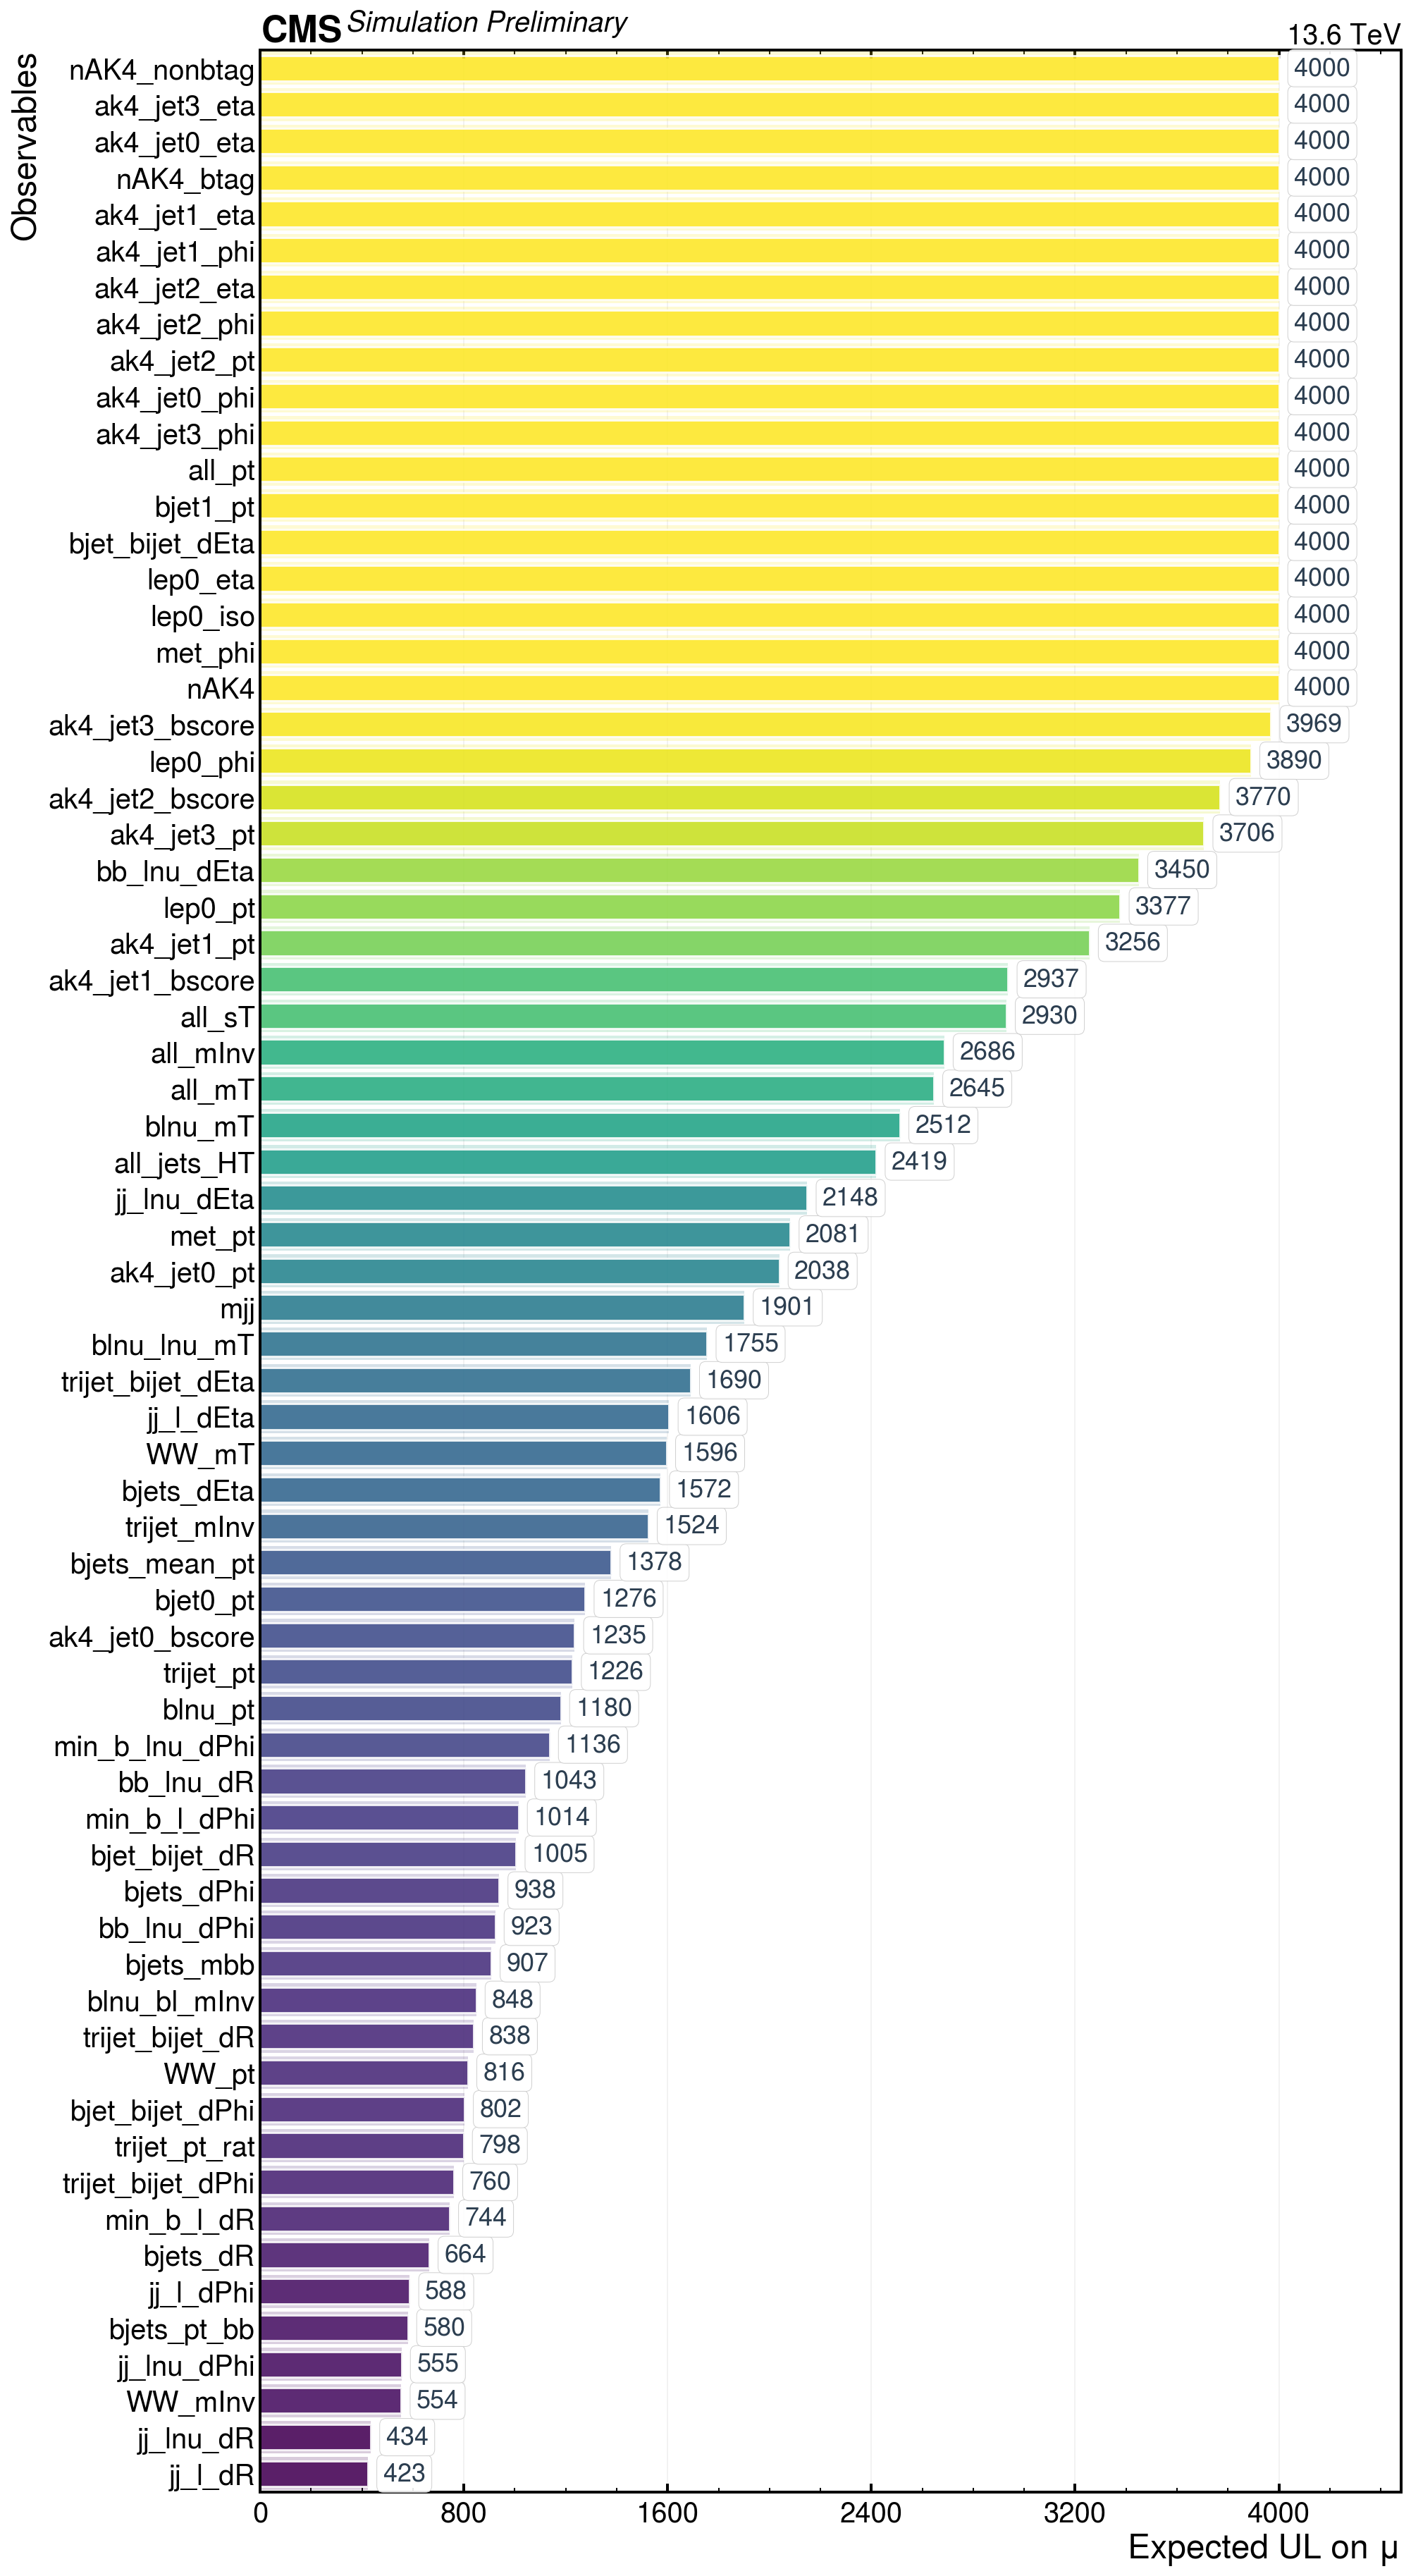

In [13]:
file_path = PROJECTDIR / 'JetTop_odd' / 'fits_new' / 'summary_results.txt'
df_vars = ResultsManager.load_summary_files(file_path)
df_vars = df_vars.sort_values('mu', ascending=True).reset_index(drop=True)
df_vars = df_vars.dropna()
custom_style = CMSPlotStyle(
    figsize=(14, max(8, len(df_vars) * 0.35 + 2)),
    label_fs=24,
    tick_fs=20,
    cms_fs=20,
    ylabel="Observables"
)
hierarchical_UL_plot(df_vars, 
                        Path('llr_study') / "UL_ranked_vars.pdf",
                        custom_style)

## crtd_final/LLR_from_vars

In [11]:
file_path = PROJECTDIR / 'crtd_final' / 'LLR_from_vars' / 'fits_new' / 'summary_results.txt'
df_llrs_from_vars = ResultsManager.load_summary_files(file_path)

CMS-style enhanced boxplot saved to llr_study/UL_boxplot_llrs_from_vars.pdf


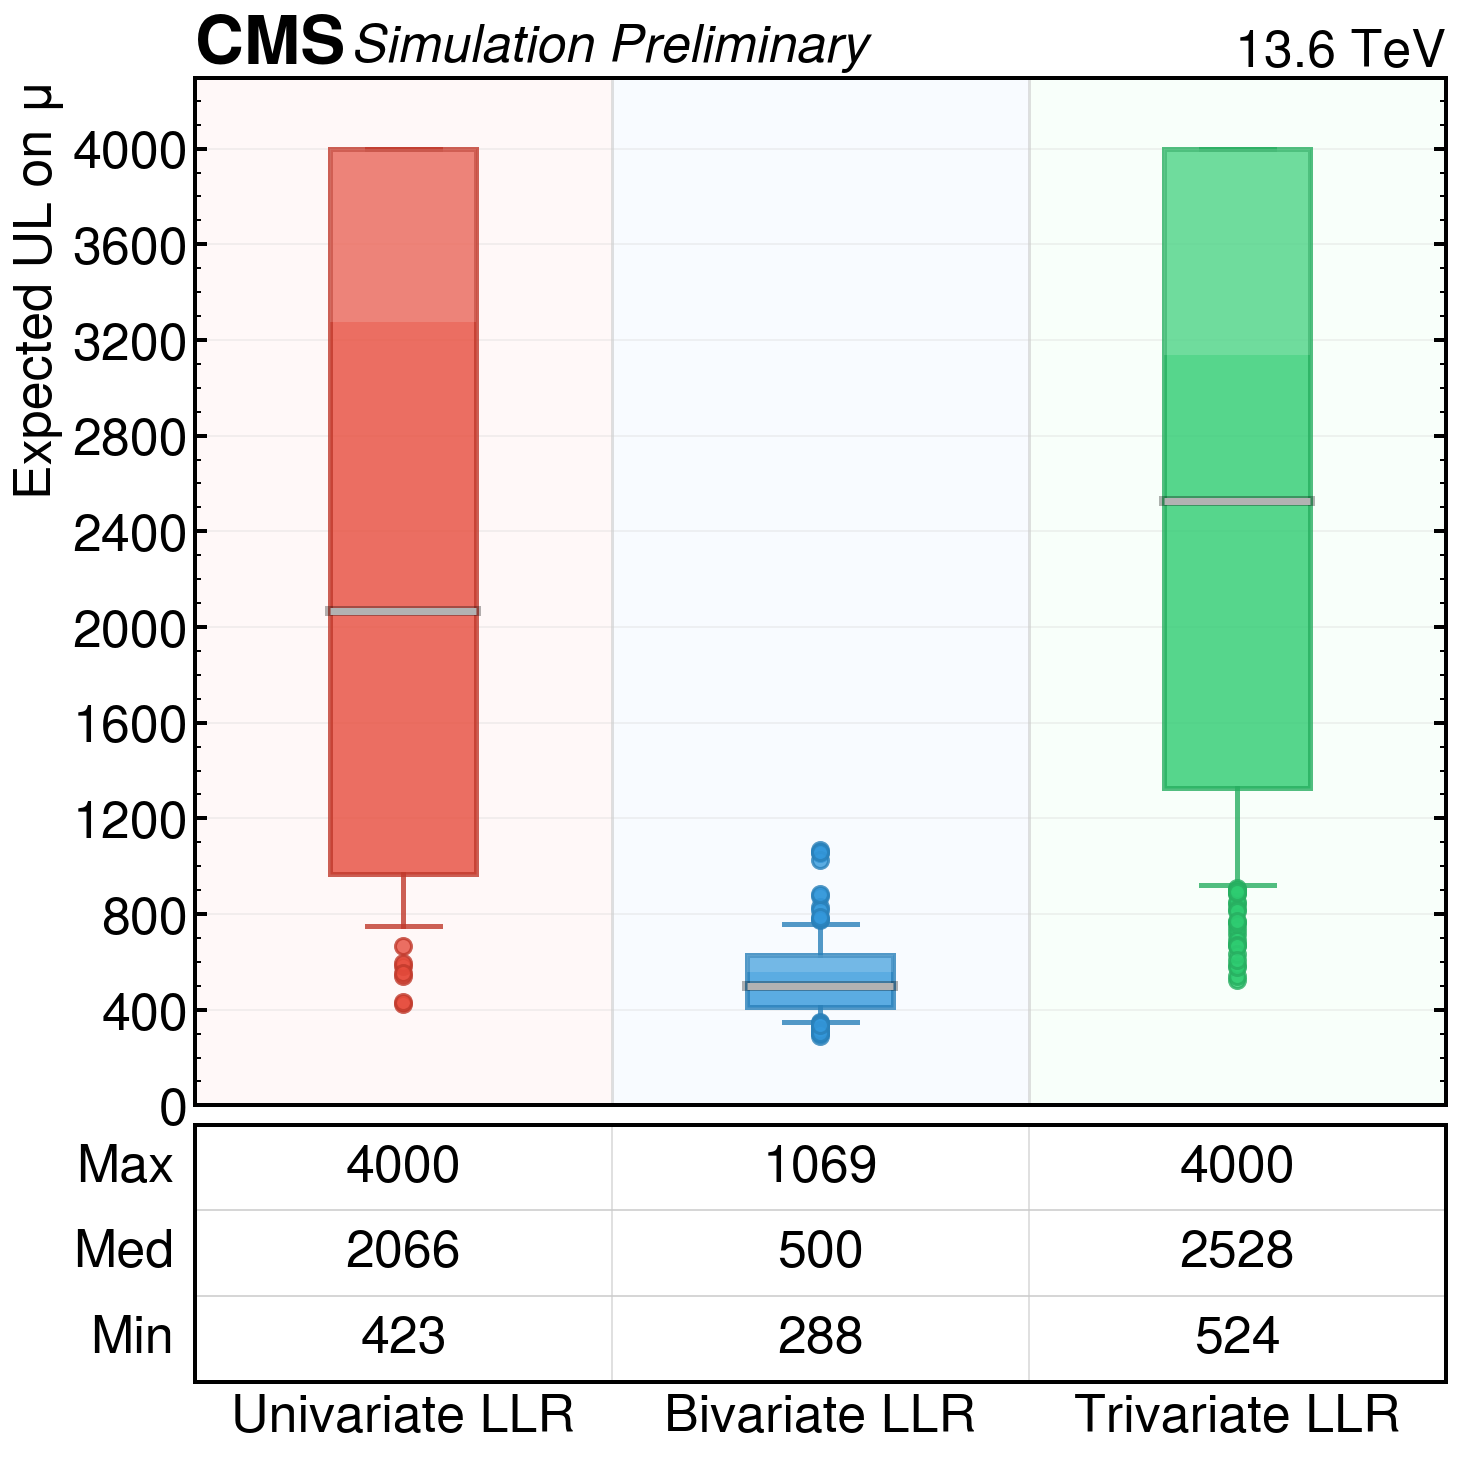

In [12]:
# xlabel='Number of Variables in LLR'
plot_style = CMSPlotStyle(figsize=(10,10), xlabel=None)
boxplot_UL_by_type_stats(df_llrs_from_vars, 
                    Path('llr_study') / 'UL_boxplot_llrs_from_vars.pdf',
                    plot_style=plot_style,
                    box_width=0.35)

CMS-style enhanced scatter plot saved to llr_study/UL_scatter_llrs_from_vars.pdf


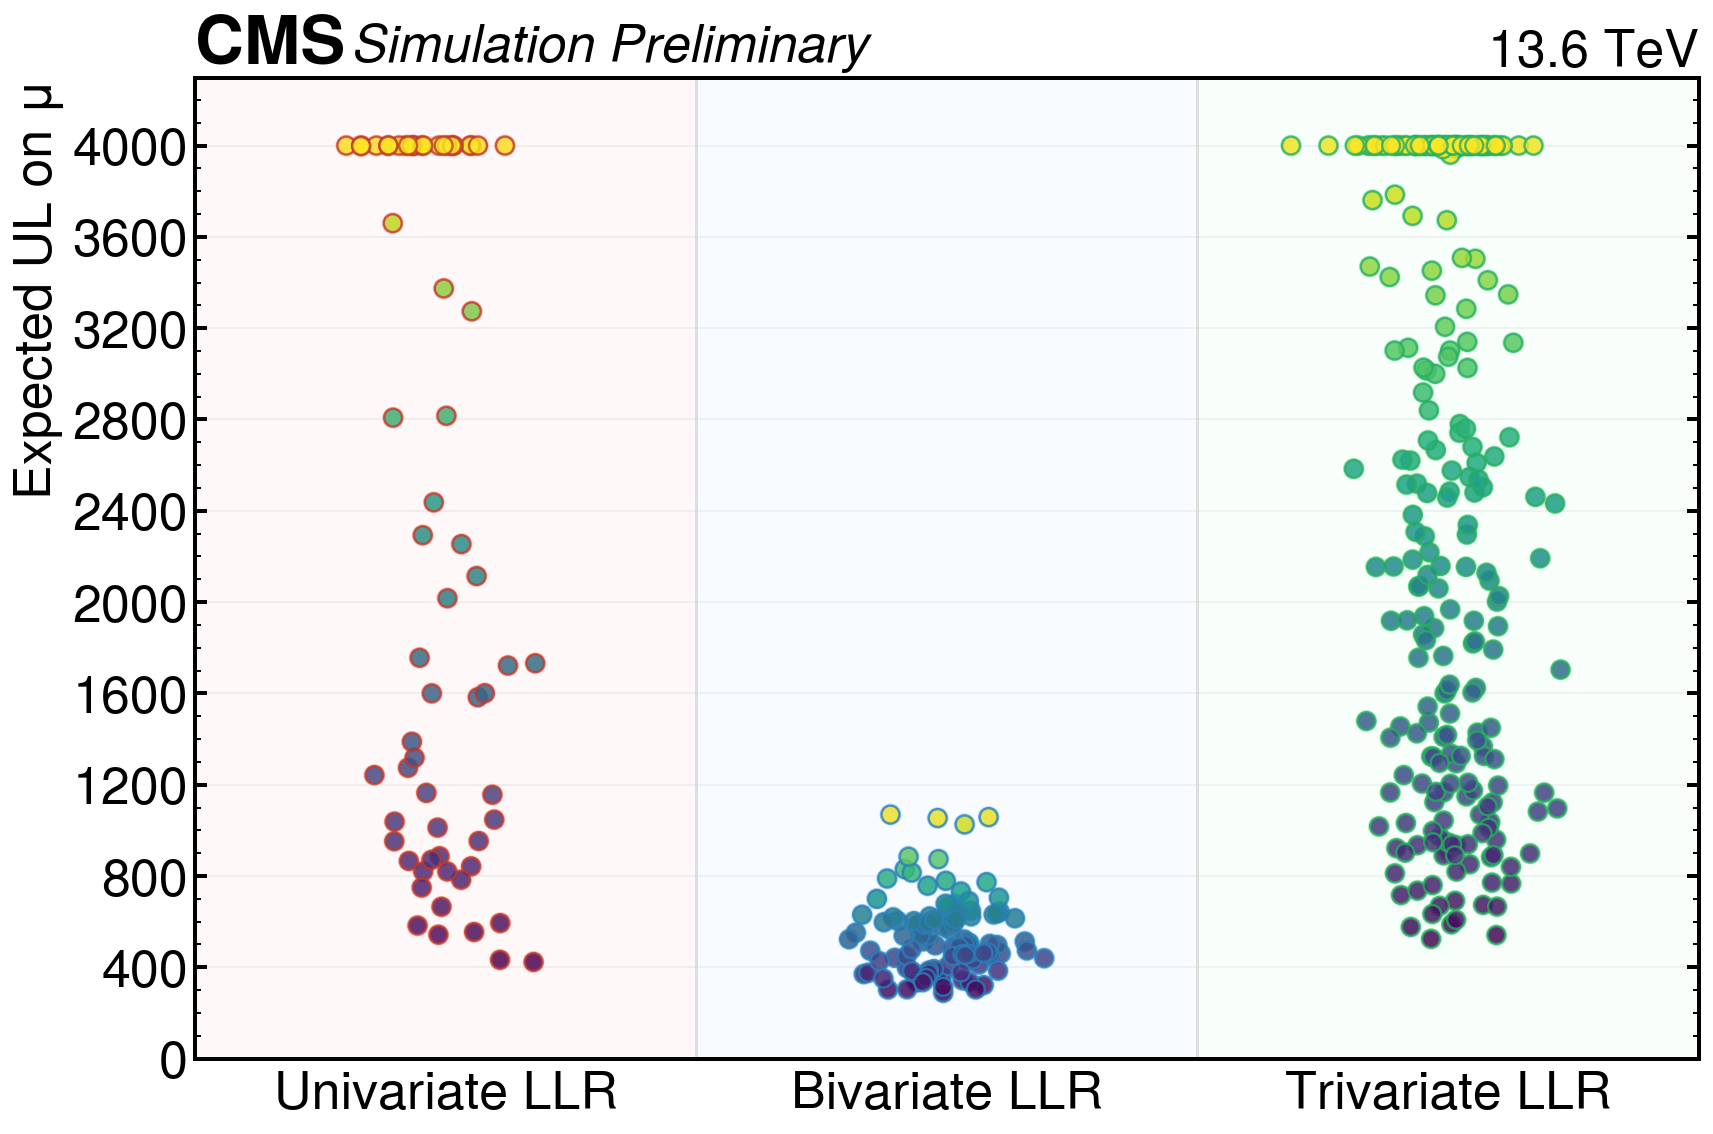

In [24]:
plot_style = CMSPlotStyle(figsize=(12,8))
scatterplot_UL_by_type(df_llrs_from_vars, 
                        Path('llr_study') / 'UL_scatter_llrs_from_vars.pdf', 
                        plot_style)

In [25]:
df_llrs_from_1D = df_llrs_from_vars[df_llrs_from_vars['obs_type'] == 'llr_from_1D']
df_llrs_from_2D = df_llrs_from_vars[df_llrs_from_vars['obs_type'] == 'llr_from_2D']
df_llrs_from_3D = df_llrs_from_vars[df_llrs_from_vars['obs_type'] == 'llr_from_3D']

In [26]:
df_llrs_from_3D['mu'].describe()

count     258.000000
mean     2568.782171
std      1249.319708
min       524.500000
25%      1326.000000
50%      2528.000000
75%      4000.000000
max      4000.000000
Name: mu, dtype: float64

CMS-style hierarchical plot saved to llr_study/UL_ranked_llrs_from_1D.pdf


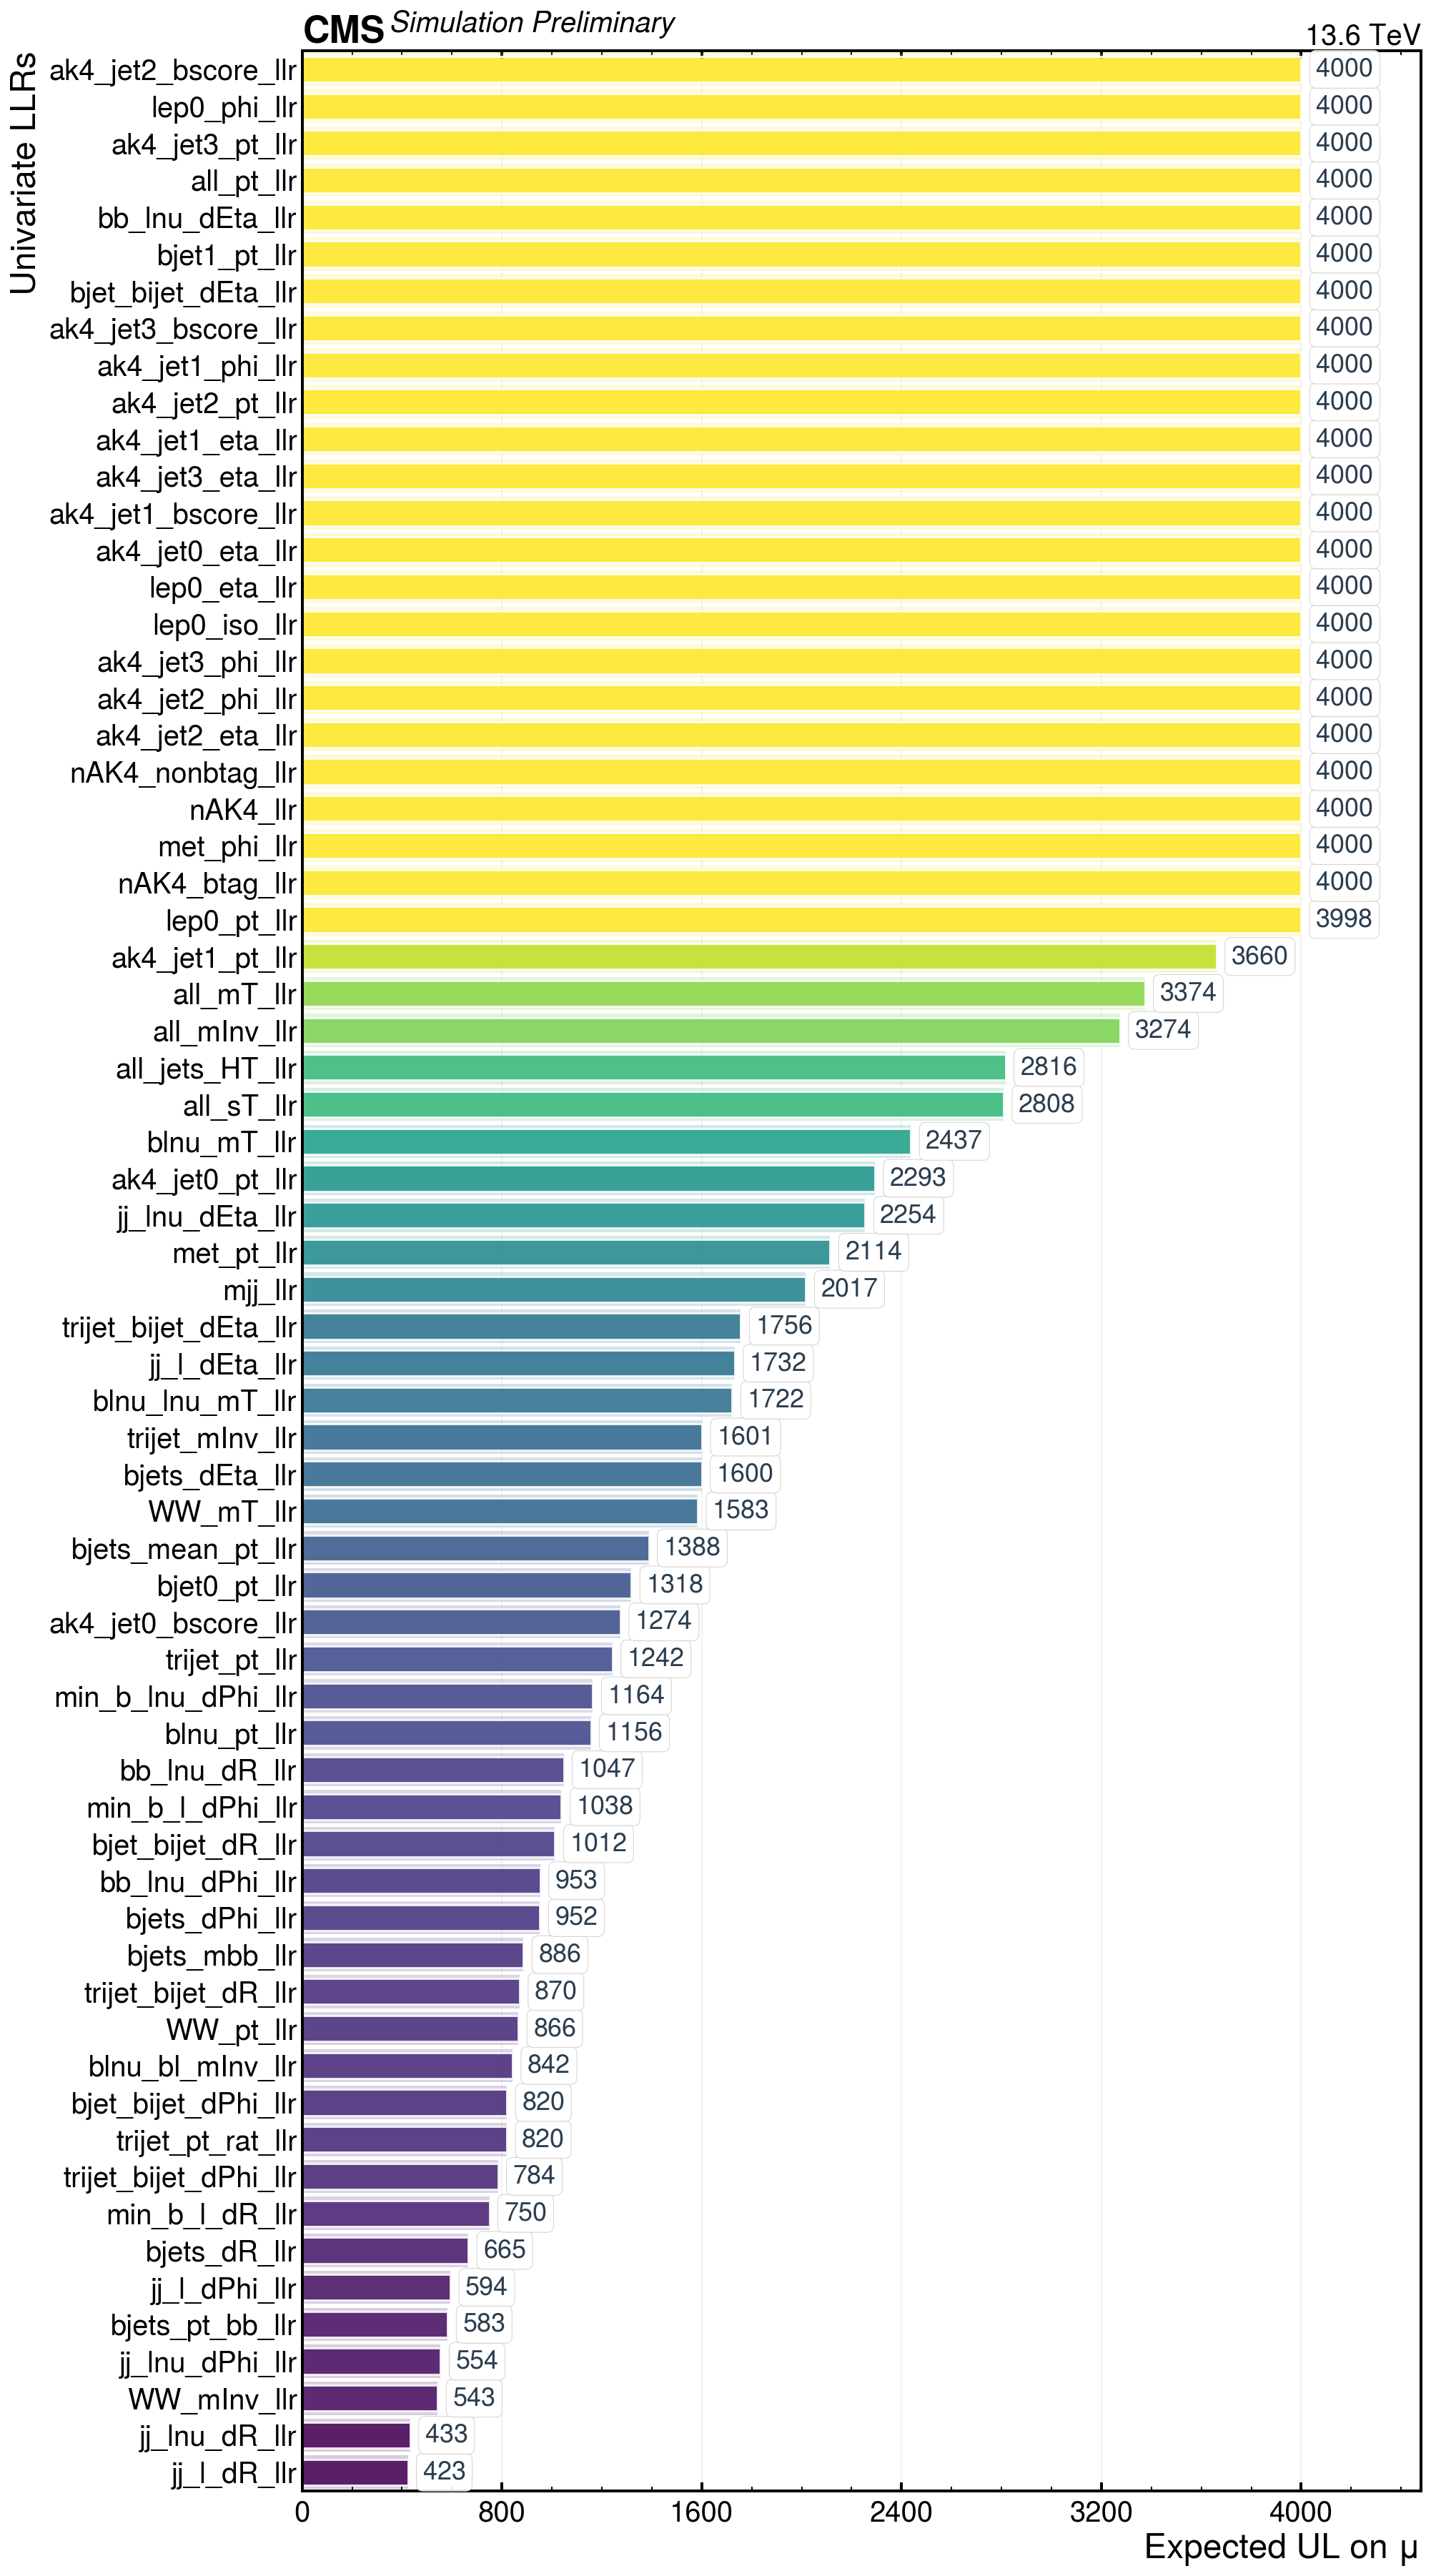

In [27]:
df_llrs_from_1D = df_llrs_from_1D.sort_values('mu', ascending=True).reset_index(drop=True)
df_llrs_from_1D = df_llrs_from_1D.dropna()
custom_style = CMSPlotStyle(
    figsize=(14, max(8, len(df_llrs_from_1D) * 0.35 + 2)),
    label_fs=24,
    tick_fs=20,
    cms_fs=20,
    ylabel="Univariate LLRs"
)
hierarchical_UL_plot(df_llrs_from_1D, 
                        Path('llr_study') / "UL_ranked_llrs_from_1D.pdf",
                        custom_style)

CMS-style hierarchical plot saved to llr_study/UL_ranked_llrs_from_2D.pdf


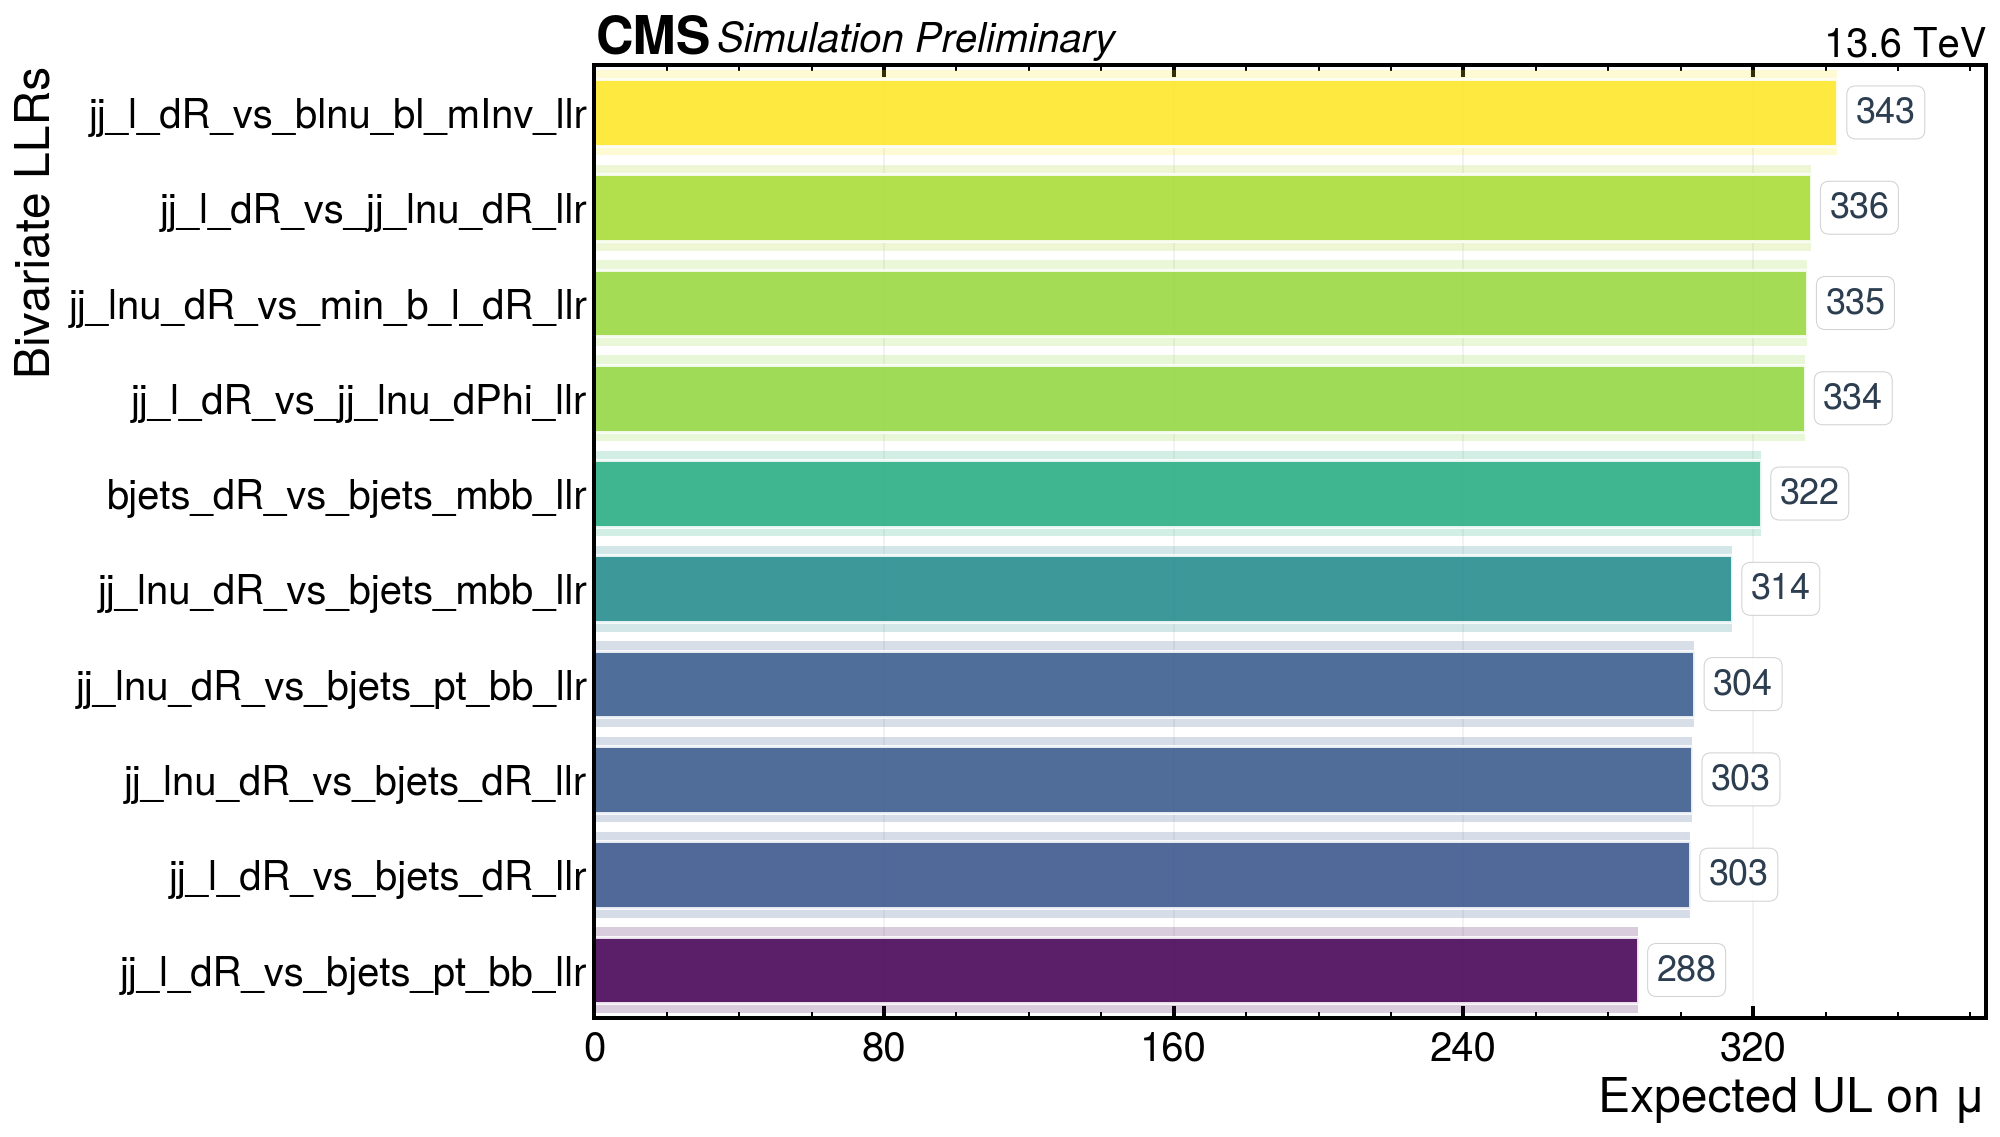

In [28]:
df_llrs_from_2D = df_llrs_from_2D.sort_values('mu', ascending=True).reset_index(drop=True)
df_llrs_from_2D_top10 = df_llrs_from_2D.head(10)
custom_style = CMSPlotStyle(
    figsize=(14, max(8, len(df_llrs_from_2D_top10) * 0.35 + 2)),
    label_fs=24,
    tick_fs=20,
    cms_fs=20,
    ylabel="Bivariate LLRs"
)
hierarchical_UL_plot(df_llrs_from_2D_top10, 
                        Path('llr_study') / "UL_ranked_llrs_from_2D.pdf",
                        custom_style)

CMS-style hierarchical plot saved to llr_study/UL_ranked_llrs_from_3D.pdf


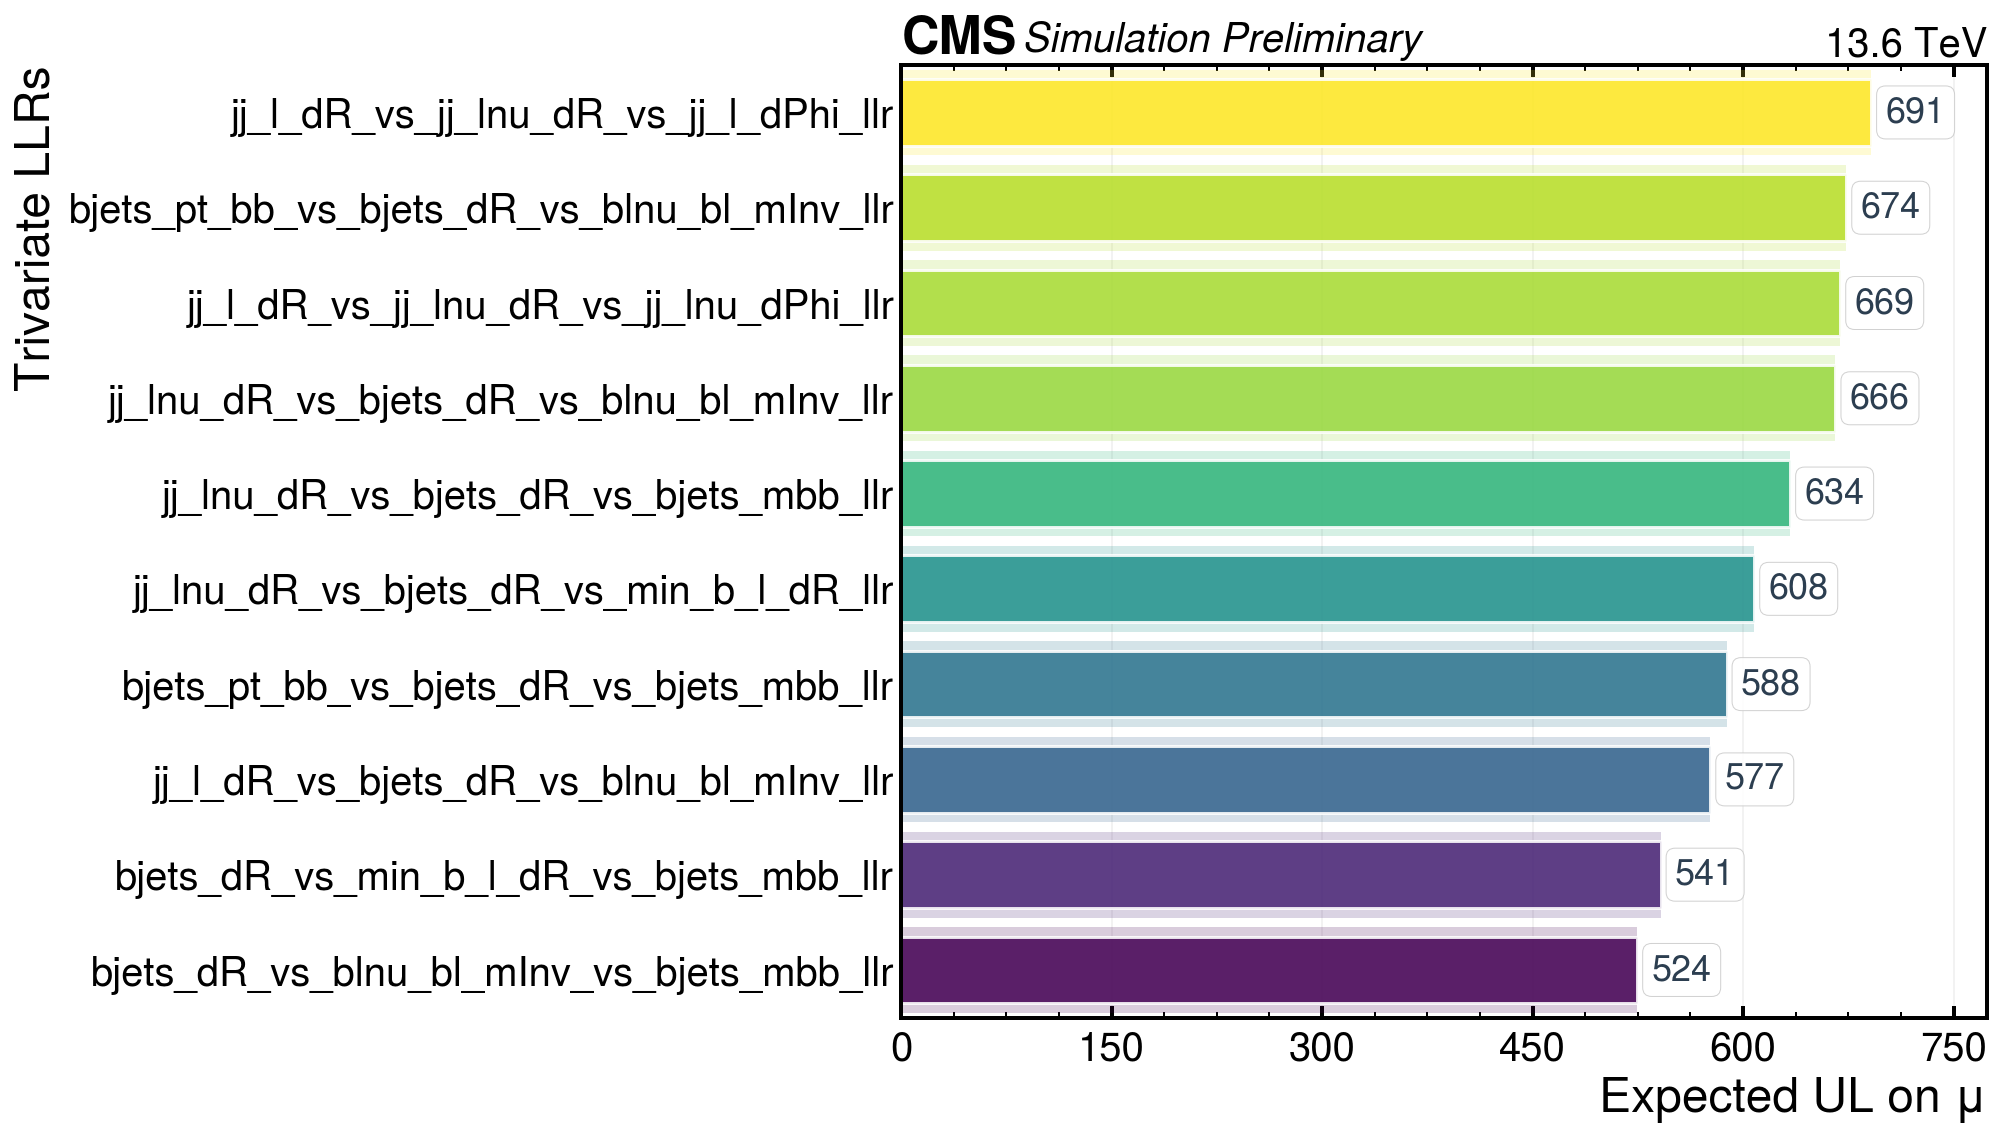

In [31]:
df_llrs_from_3D = df_llrs_from_3D.sort_values('mu', ascending=True).reset_index(drop=True)
df_llrs_from_3D_top10 = df_llrs_from_3D.head(10)
custom_style = CMSPlotStyle(
    figsize=(14, max(8, len(df_llrs_from_3D_top10) * 0.35 + 2)),
    label_fs=24,
    tick_fs=20,
    cms_fs=20,
    ylabel="Trivariate LLRs"
)
hierarchical_UL_plot(df_llrs_from_3D_top10, 
                        Path('llr_study') / "UL_ranked_llrs_from_3D.pdf",
                        custom_style)

## crtd_final/LLR_cmbs

In [1]:
subprojectdir = PROJECTDIR / 'crtd_final'
crtd_dirs = [d for d in subprojectdir.iterdir() if d.is_dir() and 'LLR_cmb' in d.name]
file_paths = [wd / 'fits_new' / 'summary_results.txt' for wd in crtd_dirs]
df_llrs_fact = ResultsManager.load_summary_files(file_paths)
df_llrs_fact

NameError: name 'PROJECTDIR' is not defined

In [10]:
df_llrs_fact[df_llrs_fact['n_variables'] == 2].describe()

,mu,sigma1_min,sigma1_max,sigma2_min,sigma2_max,n_variables
count,105.000000,105.000000,105.000000,105.000000,105.000000,105.0
mean,454.791429,326.703810,634.737143,245.814286,849.516190,2.0
std,109.145374,78.554654,151.837639,59.262640,202.416089,0.0
min,222.800000,158.500000,316.100000,117.900000,433.300000,2.0
25%,367.900000,264.400000,513.100000,199.100000,690.400000,2.0
50%,449.900000,323.200000,627.400000,243.400000,838.600000,2.0
75%,522.500000,375.400000,728.700000,282.700000,974.000000,2.0
max,769.500000,552.900000,1073.000000,416.300000,1444.000000,2.0


In [11]:
df_llrs_fact[df_llrs_fact['n_variables'] == 14].describe()

,mu,sigma1_min,sigma1_max,sigma2_min,sigma2_max,n_variables
count,15.000000,15.000000,15.000000,15.000000,15.000000,15.0
mean,166.806667,116.525333,240.160000,85.184000,330.386667,14.0
std,15.745587,11.919069,20.922947,9.368474,27.000049,0.0
min,136.800000,94.780000,198.300000,69.180000,275.700000,14.0
25%,161.600000,112.300000,233.100000,81.885000,320.900000,14.0
50%,165.200000,114.700000,239.700000,83.270000,329.900000,14.0
75%,173.200000,121.450000,249.000000,88.855000,342.100000,14.0
max,206.200000,147.700000,289.300000,110.800000,390.900000,14.0


/cvmfs/sft.cern.ch/lcg/views/LCG_105/x86_64-el9-gcc11-opt/lib/python3.9/site-packages/matplotlib/lines.py:1205: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  neq = current != val


CMS-style enhanced boxplot saved to llr_study/UL_boxplot_llrs_factorized.pdf


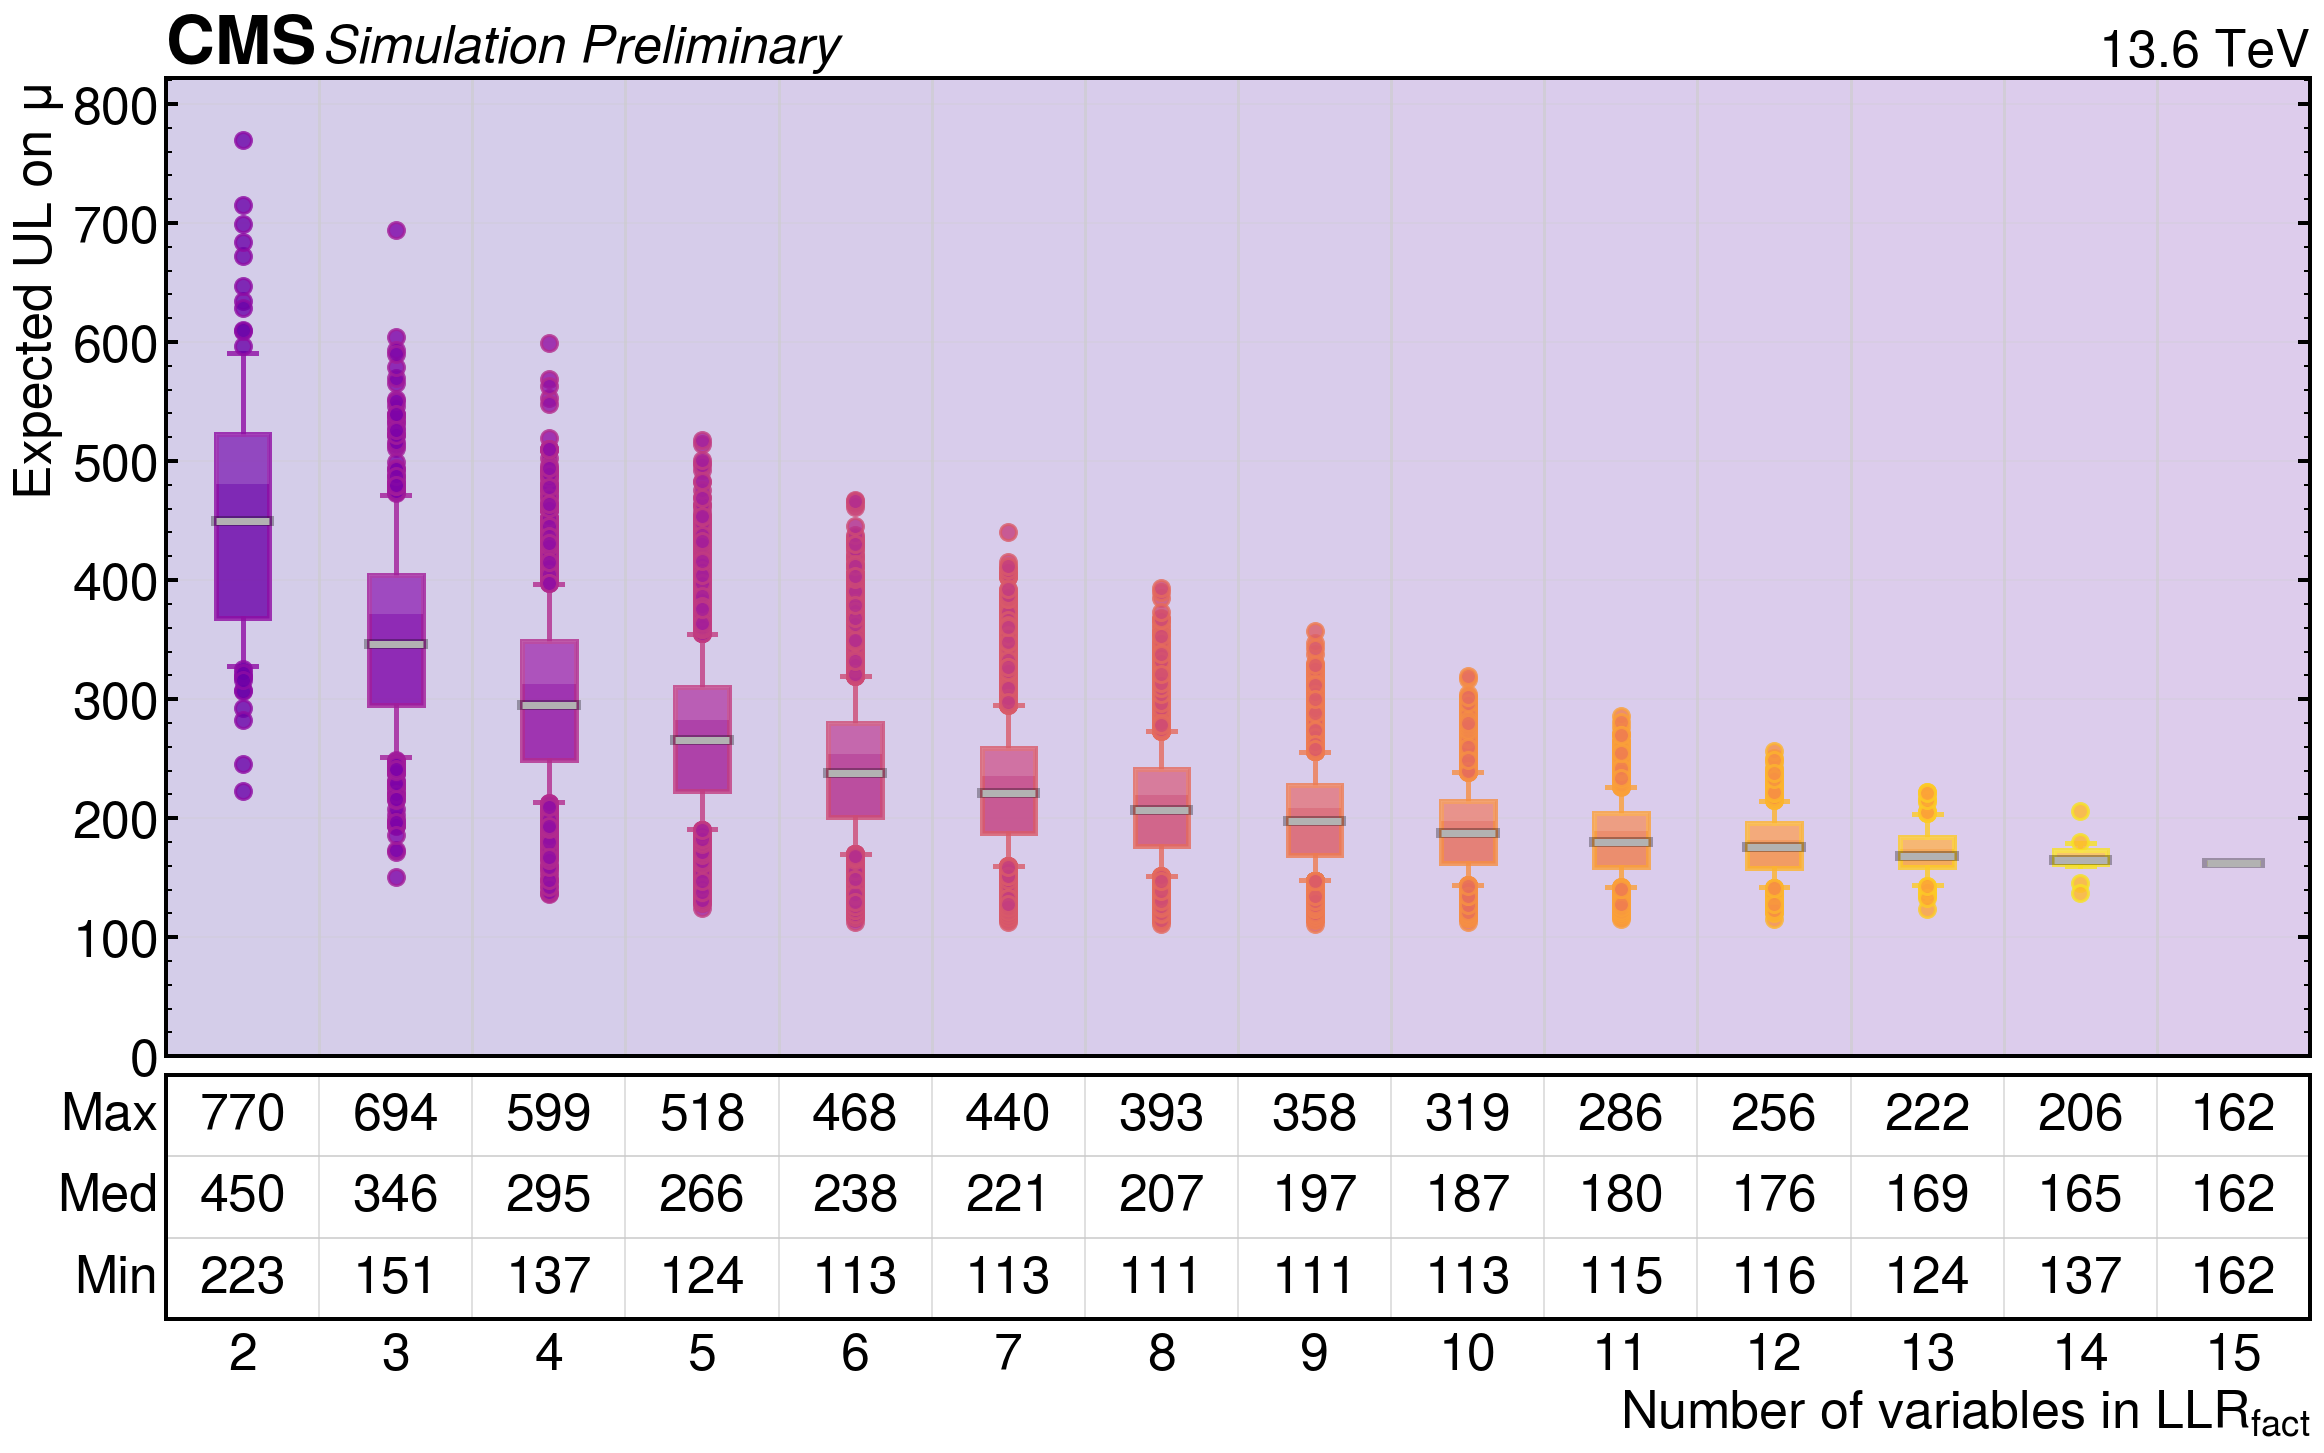

In [12]:
# xlabel='Number of Variables in LLR'
plot_style = CMSPlotStyle(figsize=(16, 10),
    xlabel=r'Number of variables in LLR$_{fact}$',
    ytick_list=list(np.arange(0, 820, 100)),
    )
boxplot_UL_by_type_stats(df_llrs_fact, 
                    Path('llr_study') / 'UL_boxplot_llrs_factorized.pdf',
                    plot_style=plot_style,
                    box_width=0.35)

/tmp/anunezde/ipykernel_53643/848972529.py:59: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(x_jitter, subset['mu'], c=plasma_colors[i], s=120, alpha=0.3, edgecolors='none', zorder=1)


CMS-style enhanced scatter plot saved to llr_study/UL_scatter_llrs_factorized.pdf


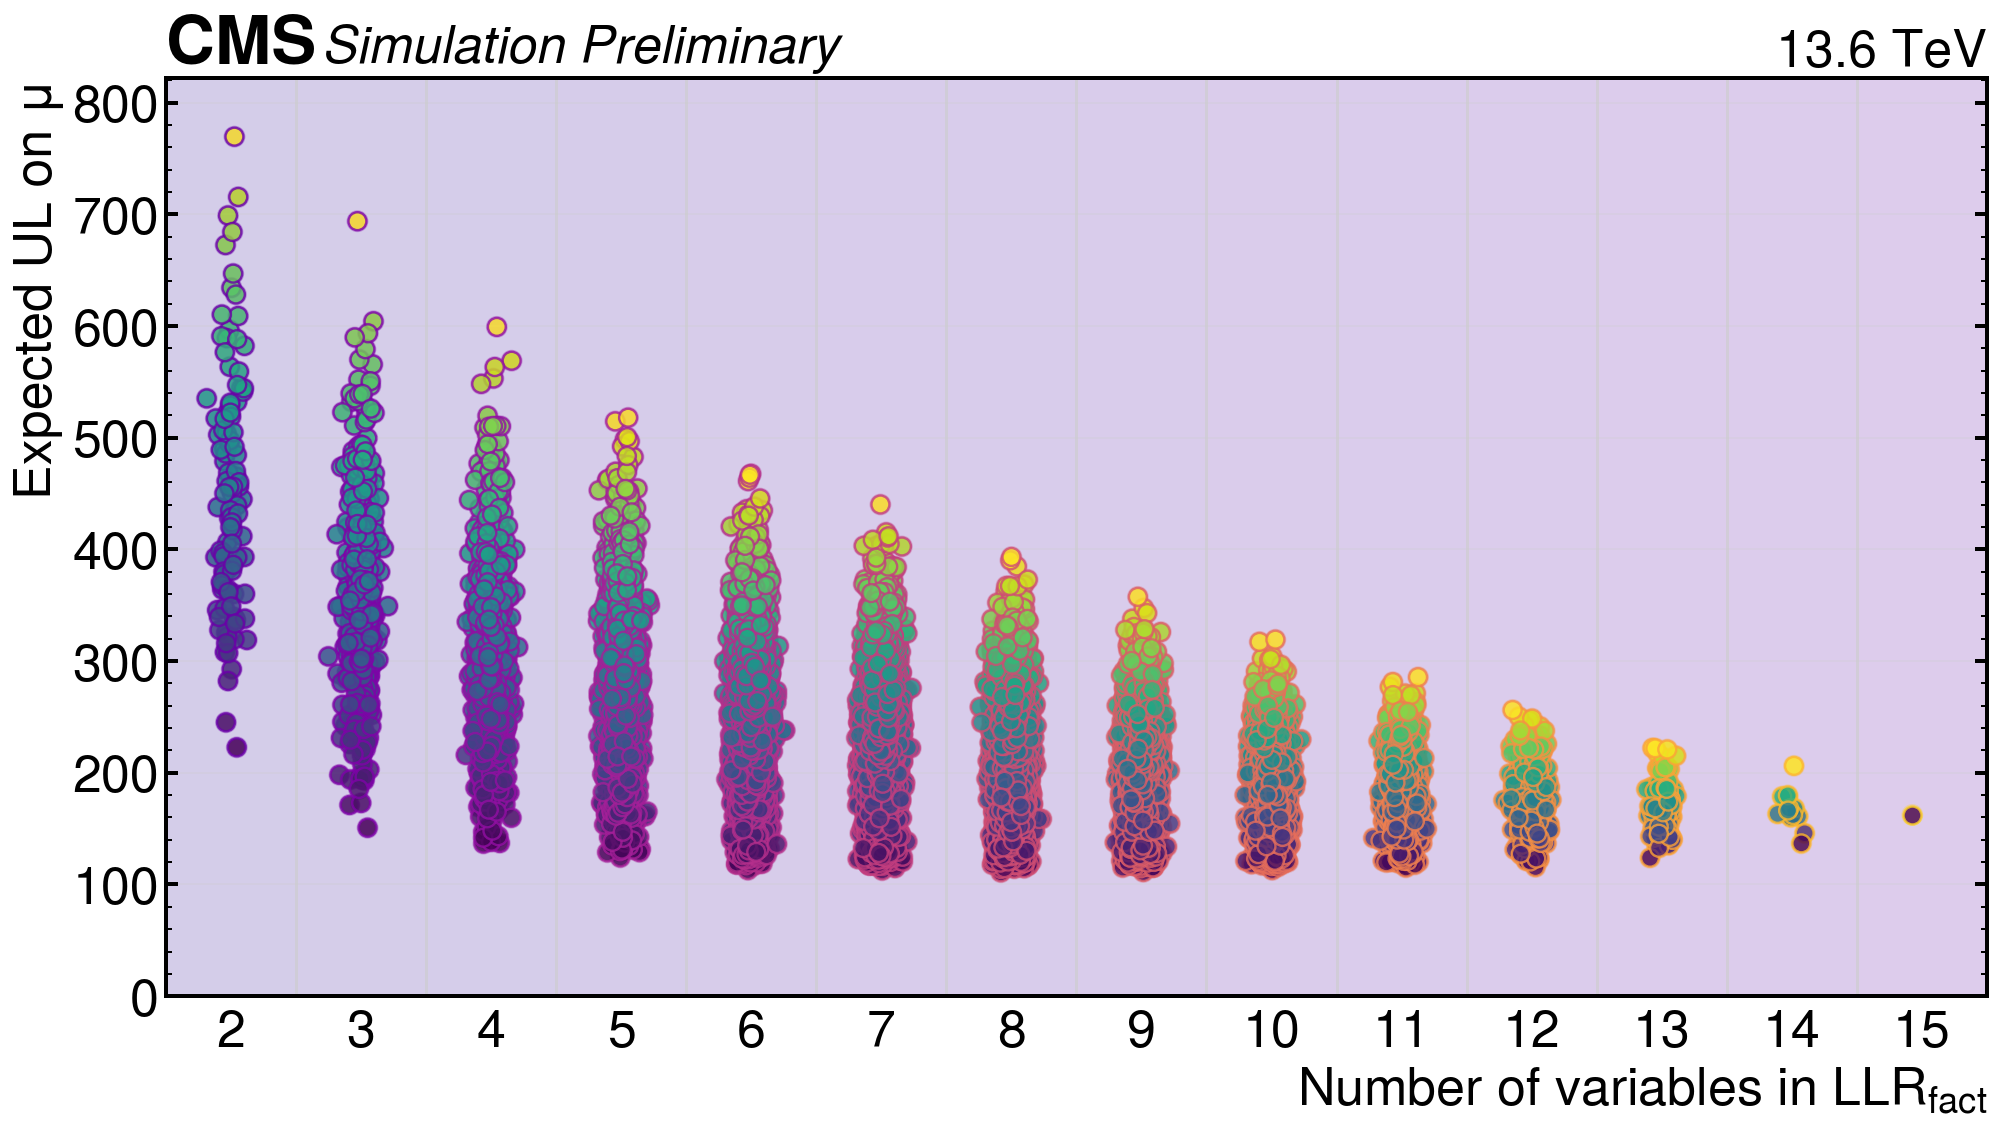

In [13]:
plot_style = CMSPlotStyle(figsize=(14, 8),
    xlabel=r'Number of variables in LLR$_{fact}$',
    ytick_list=list(np.arange(0, 820, 100)),
    )
scatterplot_UL_by_type(df_llrs_fact, 
                        Path('llr_study') / 'UL_scatter_llrs_factorized.pdf', 
                        plot_style)

CMS-style hierarchical plot saved to llr_study/UL_ranked_llrs_factorized.pdf


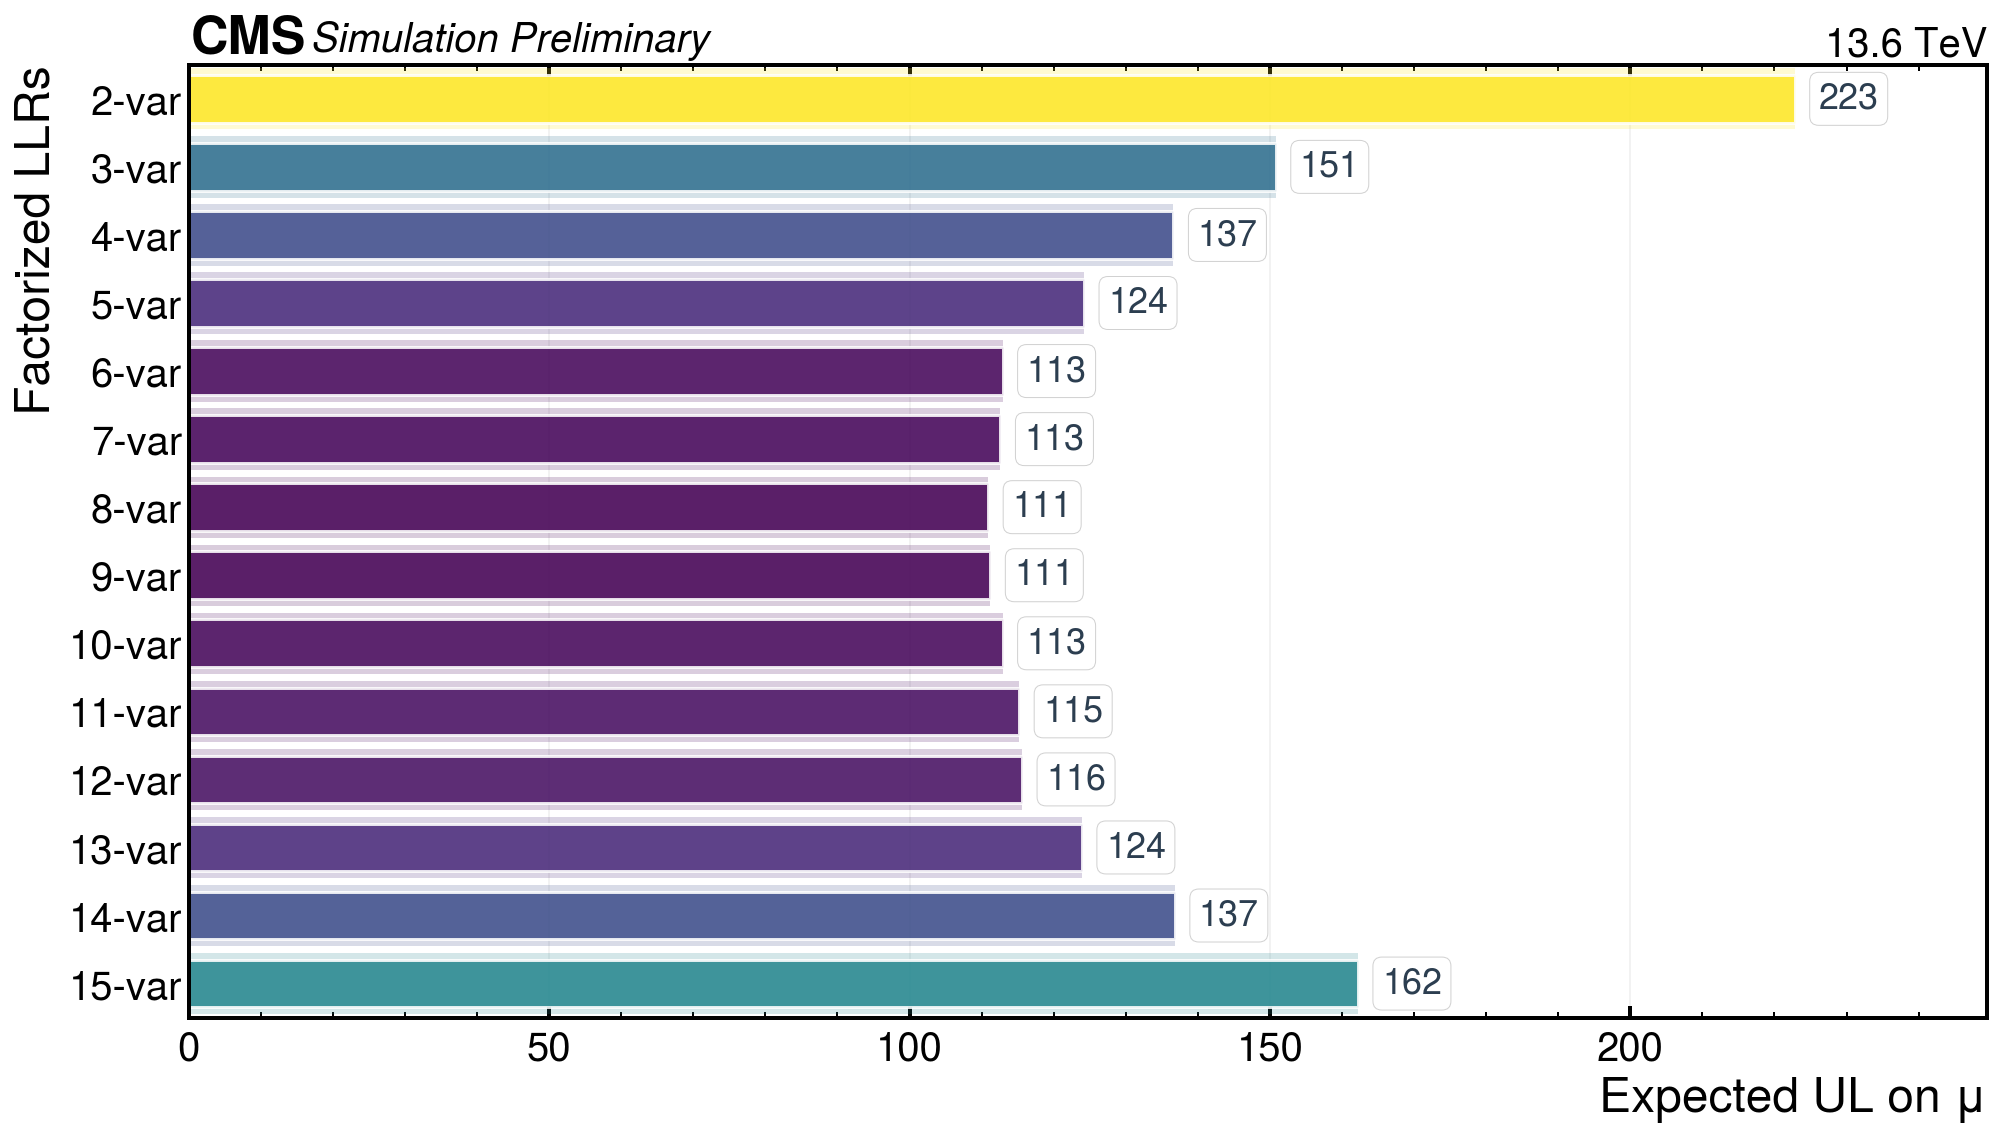

,original_obs_name,obs_name,mu
0,jj_l_dR_x_jj_lnu_dR_x_WW_mInv_x_jj_lnu_dPhi_x_bjets_pt_bb_x_jj_l_dPhi_x_bjets_dR_x_min_b_l_dR_x_trijet_bijet_dPhi_x_trijet_pt_rat_x_blnu_bl_mInv_x_WW_pt_x_trijet_bijet_dR_x_bjets_mbb_x_bjets_dPhi_llr,15-var,162.2
1,jj_l_dR_x_jj_lnu_dR_x_WW_mInv_x_jj_lnu_dPhi_x_bjets_pt_bb_x_jj_l_dPhi_x_bjets_dR_x_min_b_l_dR_x_trijet_pt_rat_x_blnu_bl_mInv_x_WW_pt_x_trijet_bijet_dR_x_bjets_mbb_x_bjets_dPhi_llr,14-var,136.8
2,jj_l_dR_x_jj_lnu_dR_x_WW_mInv_x_jj_lnu_dPhi_x_bjets_pt_bb_x_jj_l_dPhi_x_bjets_dR_x_min_b_l_dR_x_trijet_pt_rat_x_blnu_bl_mInv_x_WW_pt_x_bjets_mbb_x_bjets_dPhi_llr,13-var,123.9
3,jj_l_dR_x_jj_lnu_dR_x_WW_mInv_x_jj_lnu_dPhi_x_bjets_pt_bb_x_jj_l_dPhi_x_bjets_dR_x_min_b_l_dR_x_blnu_bl_mInv_x_WW_pt_x_bjets_mbb_x_bjets_dPhi_llr,12-var,115.6
4,jj_l_dR_x_jj_lnu_dR_x_WW_mInv_x_jj_lnu_dPhi_x_bjets_pt_bb_x_jj_l_dPhi_x_bjets_dR_x_min_b_l_dR_x_blnu_bl_mInv_x_bjets_mbb_x_bjets_dPhi_llr,11-var,115.2
5,jj_l_dR_x_jj_lnu_dR_x_WW_mInv_x_jj_lnu_dPhi_x_bjets_pt_bb_x_bjets_dR_x_trijet_pt_rat_x_blnu_bl_mInv_x_bjets_mbb_x_bjets_dPhi_llr,10-var,112.9
6,jj_l_dR_x_WW_mInv_x_bjets_pt_bb_x_bjets_dR_x_min_b_l_dR_x_trijet_pt_rat_x_blnu_bl_mInv_x_bjets_mbb_x_bjets_dPhi_llr,9-var,111.2
7,jj_l_dR_x_WW_mInv_x_bjets_pt_bb_x_jj_l_dPhi_x_blnu_bl_mInv_x_WW_pt_x_bjets_mbb_x_bjets_dPhi_llr,8-var,110.9
8,jj_l_dR_x_WW_mInv_x_jj_lnu_dPhi_x_bjets_pt_bb_x_bjets_dR_x_blnu_bl_mInv_x_bjets_mbb_llr,7-var,112.6
9,jj_l_dR_x_WW_mInv_x_jj_lnu_dPhi_x_bjets_pt_bb_x_blnu_bl_mInv_x_bjets_mbb_llr,6-var,112.9


In [17]:
best_llrs = df_llrs_fact.loc[df_llrs_fact.groupby('n_variables')['mu'].idxmin()]
best_llrs = best_llrs.sort_values('n_variables', ascending=False).reset_index(drop=True)
best_llrs['original_obs_name'] = best_llrs['obs_name'].copy()
best_llrs['obs_name'] = best_llrs['n_variables'].apply(lambda n: f'{n}-var')
custom_style = CMSPlotStyle(
    figsize=(14, max(8, len(best_llrs) * 0.35 + 2)),
    label_fs=24,
    tick_fs=20,
    cms_fs=20,
    ylabel="Factorized LLRs"
)
hierarchical_UL_plot(best_llrs, 
                    Path('llr_study') / "UL_ranked_llrs_factorized.pdf",
                    custom_style)
pd.set_option('display.max_colwidth', None)
best_llrs[['original_obs_name', 'obs_name', 'mu']]

In [38]:
best_llrs.loc[7]['original_obs_name']

'jj_l_dR_x_WW_mInv_x_bjets_pt_bb_x_jj_l_dPhi_x_blnu_bl_mInv_x_WW_pt_x_bjets_mbb_x_bjets_dPhi_llr'

# All ULs

/cvmfs/sft.cern.ch/lcg/views/LCG_105/x86_64-el9-gcc11-opt/lib/python3.9/site-packages/matplotlib/lines.py:1205: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  neq = current != val


CMS-style enhanced boxplot saved to llr_study/UL_boxplot_llrs.pdf


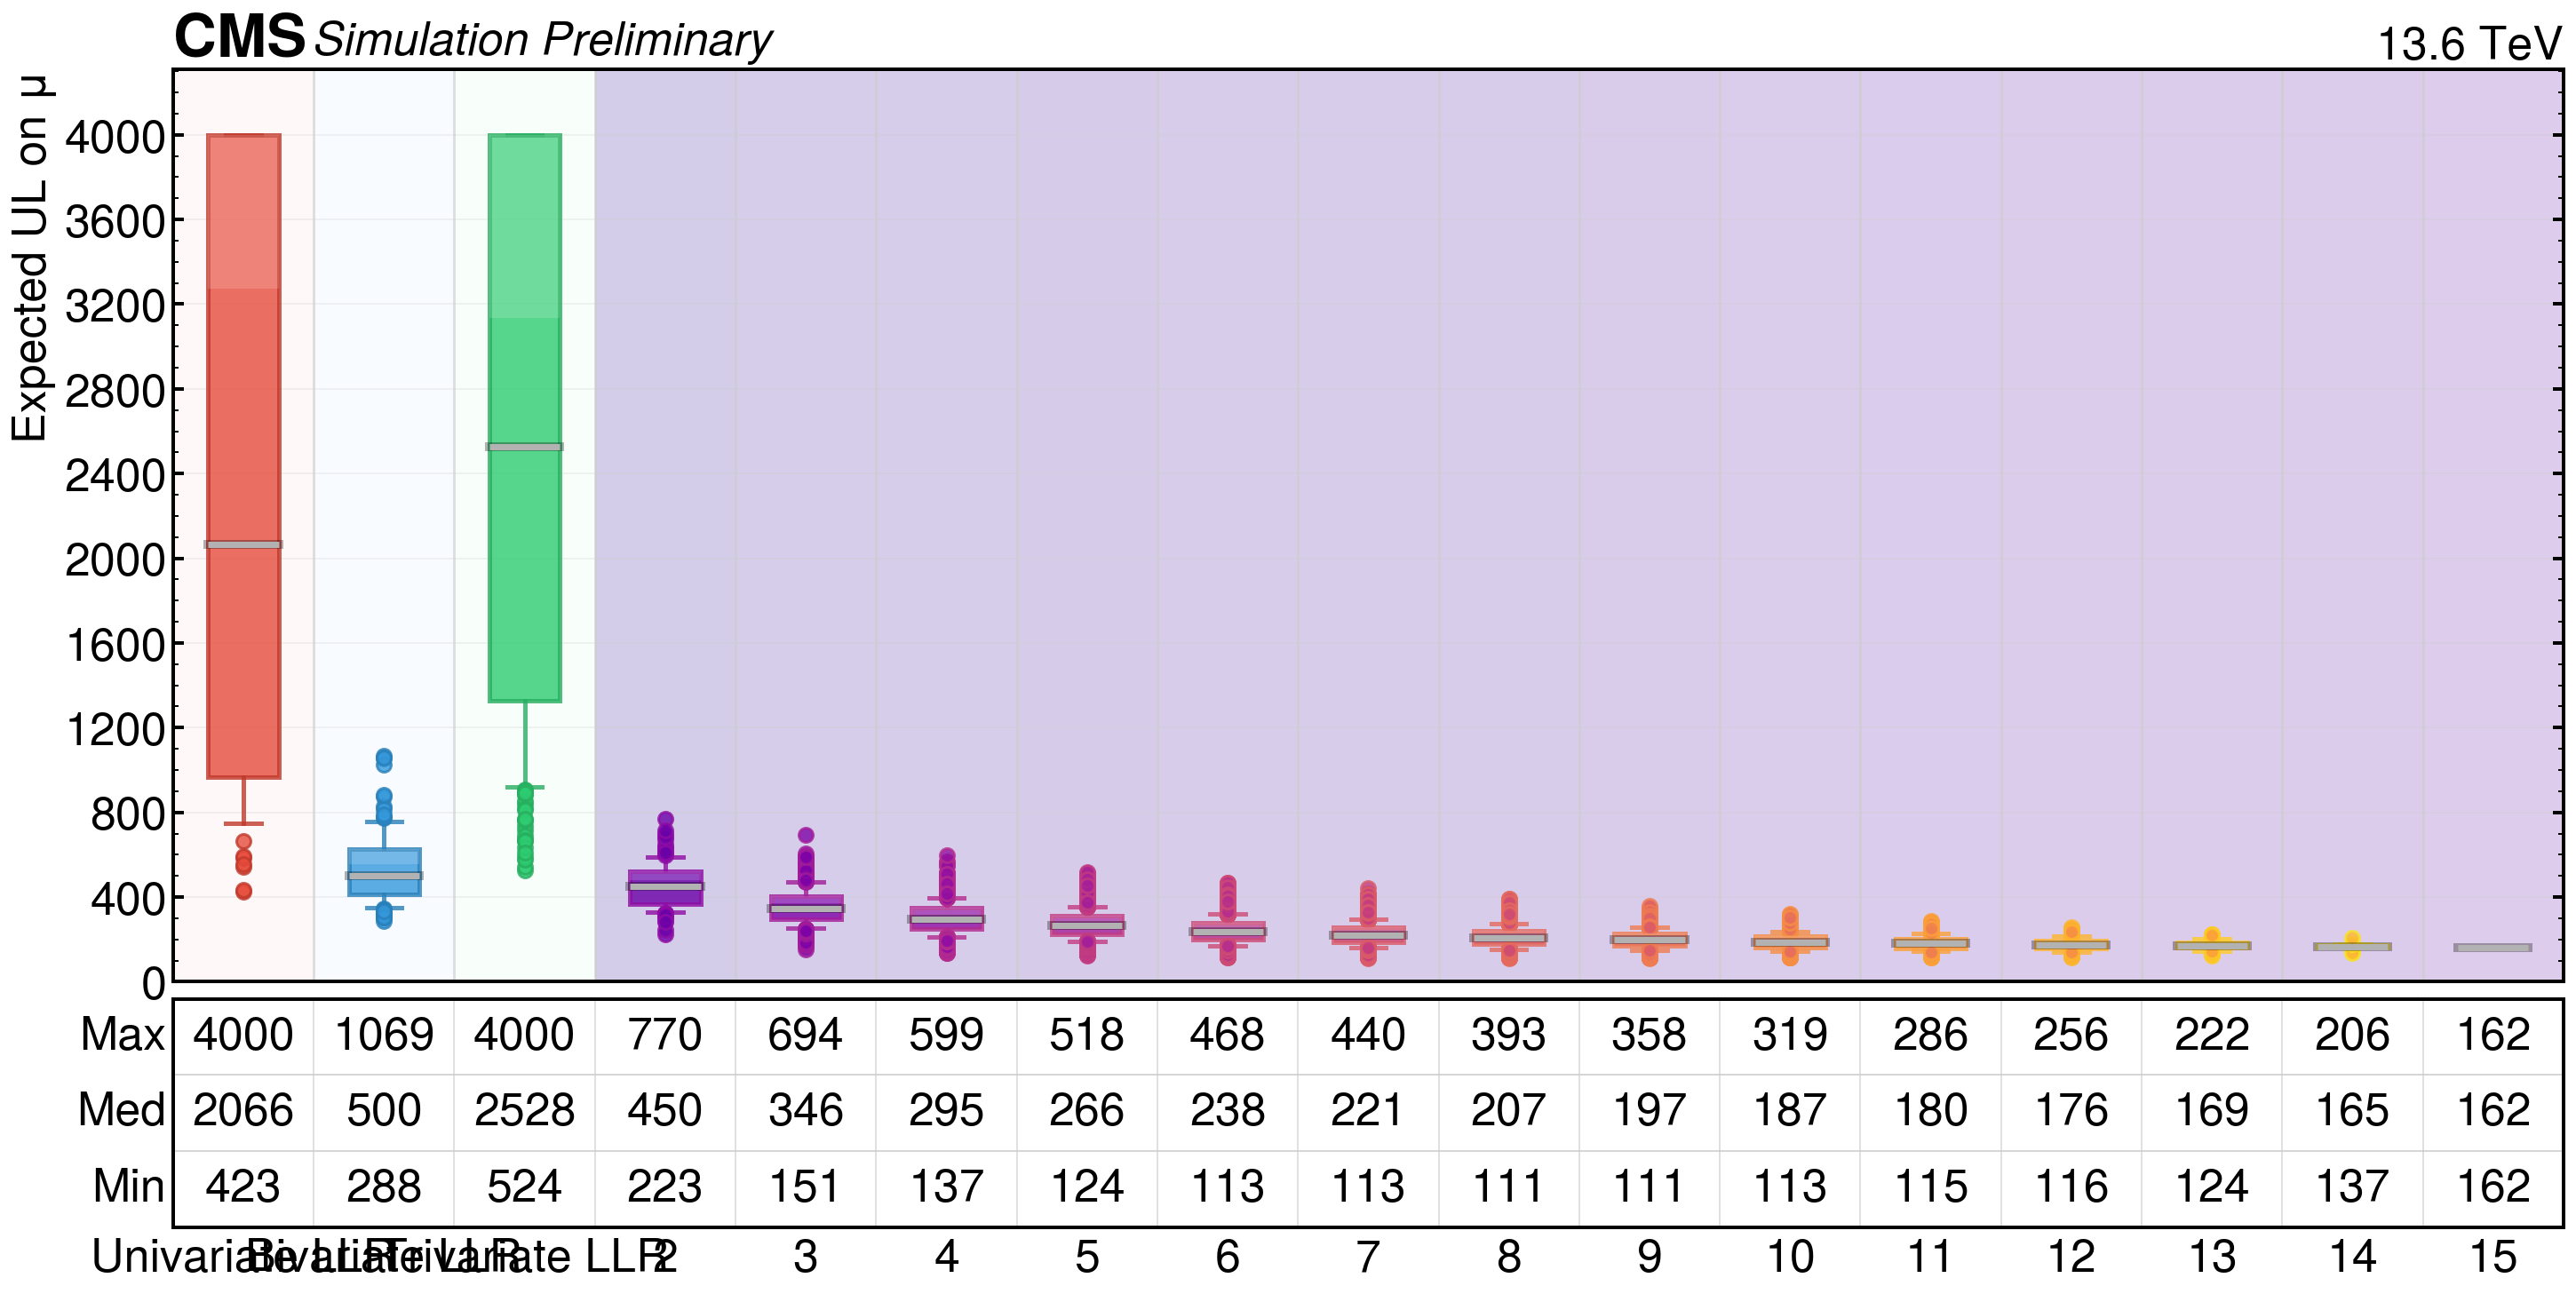

In [39]:
df_full = pd.concat([df_llrs_fact, df_llrs_from_vars])
plot_style = CMSPlotStyle(
    figsize=(20, 10),
    xlabel=None,
    ytick_list=list(np.arange(0, 4200, 400))
)
boxplot_UL_by_type_stats(df_full, 
                    Path('llr_study') / 'UL_boxplot_llrs.pdf', 
                    plot_style)

## crtd_final/LR_from_vars

In [25]:
file_path = PROJECTDIR / 'crtd_final' / 'LR_from_vars' / 'fits_new' / 'summary_results.txt'
df_lrs_from_vars = ResultsManager.load_summary_files(file_path)
df_lrs_from_vars = df_lrs_from_vars.sort_values('mu', ascending=True).reset_index(drop=True)
df_lrs_from_vars = df_lrs_from_vars.dropna()
df_lrs_from_vars.head(15)

,obs_name,mu,sigma1_min,sigma1_max,sigma2_min,sigma2_max,obs_type,n_variables
0,jj_l_dR_vs_bjets_dR_lr,309.8,222.7,432.0,167.0,581.4,var_2D,2
1,jj_l_dR_vs_jj_lnu_dR_lr,314.6,226.3,438.8,169.6,590.5,var_2D,2
2,jj_lnu_dR_vs_bjets_mbb_lr,319.9,229.5,446.1,172.4,600.4,var_2D,2
3,jj_lnu_dR_vs_bjets_dR_lr,323.2,231.9,450.8,174.3,606.7,var_2D,2
4,jj_l_dR_vs_jj_lnu_dPhi_lr,324.5,232.8,452.6,174.9,609.1,var_2D,2
5,jj_l_dR_vs_bjets_mbb_lr,331.2,237.6,462.0,178.6,621.7,var_2D,2
6,jj_lnu_dR_vs_min_b_l_dR_lr,333.2,239.0,464.8,179.6,625.5,var_2D,2
7,bjets_dR_vs_bjets_mbb_lr,336.2,241.2,468.9,181.3,631.1,var_2D,2
8,bjets_pt_bb_vs_bjets_dR_lr,337.9,242.8,471.3,182.8,634.3,var_2D,2
9,jj_lnu_dR_vs_jj_l_dPhi_lr,338.0,242.5,471.4,182.2,634.4,var_2D,2


In [26]:
file_path = PROJECTDIR / 'crtd_final' / 'LLR_from_vars' / 'fits_new' / 'summary_results.txt'
df_lrs_from_vars = ResultsManager.load_summary_files(file_path)
df_lrs_from_vars = df_lrs_from_vars.sort_values('mu', ascending=True).reset_index(drop=True)
df_lrs_from_vars = df_lrs_from_vars.dropna()
df_lrs_from_vars.head(15)

,obs_name,mu,sigma1_min,sigma1_max,sigma2_min,sigma2_max,obs_type,n_variables
0,jj_l_dR_vs_bjets_pt_bb_llr,288.2,206.9,404.3,154.8,542.6,llr_from_2D,2
1,jj_l_dR_vs_bjets_dR_llr,302.6,217.1,422.0,163.1,568.0,llr_from_2D,2
2,jj_lnu_dR_vs_bjets_dR_llr,303.2,218.1,425.3,163.5,570.9,llr_from_2D,2
3,jj_lnu_dR_vs_bjets_pt_bb_llr,303.8,218.1,426.0,163.1,571.8,llr_from_2D,2
4,jj_lnu_dR_vs_bjets_mbb_llr,314.2,226.2,440.8,168.8,591.6,llr_from_2D,2
5,bjets_dR_vs_bjets_mbb_llr,322.2,231.2,449.4,173.7,604.8,llr_from_2D,2
6,jj_l_dR_vs_jj_lnu_dPhi_llr,334.2,240.2,466.2,180.8,627.4,llr_from_2D,2
7,jj_lnu_dR_vs_min_b_l_dR_llr,334.8,240.9,468.2,179.8,629.2,llr_from_2D,2
8,jj_l_dR_vs_jj_lnu_dR_llr,335.9,241.3,468.4,181.7,626.1,llr_from_2D,2
9,jj_l_dR_vs_blnu_bl_mInv_llr,343.2,246.8,481.4,185.0,641.8,llr_from_2D,2
